# Исследовательский анализ данных в Python и проверка гипотез.

### **Цель:** Провести исследовательский анализ данных рынка сервиса Яндекс Афиша и проверить гипотезы.   

### **Задачи:**
1. Загрузить данные и познакомиться с их содержимым.
2. Провести предобработку данных.
3. Провести исследовательский анализ данных.
4. Сформулировать выводы по проведённому анализу.
5. Проверить сформулированные гипотезы.


### Данные

Для анализа поступили данные о бронировании билетов на сервисе Яндекс Афиша за период с 1 июня по 31 октября 2024 года. Данные состоят из трех датасетов:

- `final_tickets_orders_df.csv` — информация обо всех заказах билетов, совершённых с двух типов устройств — мобильных и стационарных. ;
- `final_tickets_events_df.csv` —  информация о событиях, включая город и регион события, а также информацию о площадке проведения мероприятия;
- `final_tickets_tenge_df.csv` – информация о курсе тенге к российскому рублю за 2024 год. 

### Описание датасета `final_tickets_orders_df`

- `order_id` — уникальный идентификатор заказа.
- `user_id` — уникальный идентификатор пользователя.
- `created_dt_msk` — дата создания заказа (московское время).
- `created_ts_msk` — дата и время создания заказа (московское время).
- `event_id` — идентификатор мероприятия из таблицы events.
- `cinema_circuit` — сеть кинотеатров. Если не применимо, то здесь будет значение 'нет'.
- `age_limit` — возрастное ограничение мероприятия.
- `currency_code` — валюта оплаты, например rub для российских рублей.
- `device_type_canonical` — тип устройства, с которого был оформлен заказ, например mobile для мобильных устройств, desktop для стационарных.
- `revenue` — выручка от заказа.
- `service_name` — название билетного оператора.
- `tickets_count` — количество купленных билетов.
- `total` — общая сумма заказа.

### Описание датасета `final_tickets_events_df`

- `event_id` — уникальный идентификатор мероприятия.
- `event_name` — название мероприятия. Аналог поля event_name_code из исходной базы данных.
- `event_type_description` — описание типа мероприятия.
- `event_type_main` — основной тип мероприятия: театральная постановка, концерт и так далее.
- `organizers` — организаторы мероприятия.
- `region_name` — название региона.
- `city_name` — название города.
- `venue_id` — уникальный идентификатор площадки.
- `venue_name` — название площадки.
- `venue_address` — адрес площадки.

### Описание датасета `final_tickets_tenge_df`
- `nominal` — номинал (100 тенге);
- `data` — дата;
- `curs` — курс тенге к рублю;
- `cdx` — обозначение валюты (kzt).

### Структура проекта

1. Загрузка данных и знакомство с ними.
2. Предобработка данных.
3. Исследовательский анализ данных.
4. Статистический анализ данных
5. Итоговые выводы.

---


### 1. Загрузка данных и знакомство с ними
#### 1.1. Первчиный просмотр данных
Начнём с загрузки библиотек и датасетов `final_tickets_orders_df` и `final_tickets_events_df`, `final_tickets_tenge_df`. Будем использовать pandas и библиотеки визуализации данных matplotlib и seaborn. Данные датасетов сохраним в трех переменных: `orders` и `events`, `tenge`.

In [1]:
# Импортируем библиотеки
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
import os

# Пытаемся загрузить с локального пути, если нет - с серверного
try:
    orders = pd.read_csv('C:/Users/mobil/Downloads/final_tickets_orders_df.csv') 
    events = pd.read_csv('C:/Users/mobil/Downloads/final_tickets_events_df.csv')
    tenge = pd.read_csv('C:/Users/mobil/Downloads/final_tickets_tenge_df.csv')
    print("Локальная загрузка")
except FileNotFoundError:
    orders = pd.read_csv('/datasets/final_tickets_orders_df.csv')
    events = pd.read_csv('/datasets/final_tickets_events_df.csv')
    tenge = pd.read_csv('/datasets/final_tickets_tenge_df.csv')
    print("Серверная загрузка")

Локальная загрузка


In [3]:
orders[:5]

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,Край билетов,4,10870.99,NaN
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,Мой билет,2,2067.51,NaN
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,За билетом!,4,13984.16,75.0
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,Лови билет!,2,212.28,NaN
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,Билеты без проблем,3,10695.43,83.0


In [4]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_id               290849 non-null  int64  
 1   user_id                290849 non-null  object 
 2   created_dt_msk         290849 non-null  object 
 3   created_ts_msk         290849 non-null  object 
 4   event_id               290849 non-null  int64  
 5   cinema_circuit         290849 non-null  object 
 6   age_limit              290849 non-null  int64  
 7   currency_code          290849 non-null  object 
 8   device_type_canonical  290849 non-null  object 
 9   revenue                290849 non-null  float64
 10  service_name           290849 non-null  object 
 11  tickets_count          290849 non-null  int64  
 12  total                  290849 non-null  float64
 13  days_since_prev        268909 non-null  float64
dtypes: float64(3), int64(4), object(7)
m

In [5]:
events[:5]

,event_id,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4436,e4f26fba-da77-4c61-928a-6c3e434d793f,спектакль,театр,№4893,Североярская область,Озёрск,2,1600,"Кладбище искусств ""Проблема"" и партнеры","наб. Загородная, д. 785"
1,5785,5cc08a60-fdea-4186-9bb2-bffc3603fb77,спектакль,театр,№1931,Светополянский округ,Глиноград,54,2196,"Лекции по искусству ""Свет"" Групп","ул. Ягодная, д. 942"
2,8817,8e379a89-3a10-4811-ba06-ec22ebebe989,спектакль,театр,№4896,Североярская область,Озёрск,2,4043,"Кинокомитет ""Золотая"" Инк","ш. Коммуны, д. 92 стр. 6"
3,8849,682e3129-6a32-4952-9d8a-ef7f60d4c247,спектакль,театр,№4960,Каменевский регион,Глиногорск,213,1987,"Выставка ремесел ""Свет"" Лтд","пер. Набережный, д. 35"
4,8850,d6e99176-c77f-4af0-9222-07c571f6c624,спектакль,театр,№4770,Лесодальний край,Родниковец,55,4230,"Фестивальный проект ""Листья"" Групп","пер. Проезжий, д. 9"


In [6]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22427 entries, 0 to 22426
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   event_id                22427 non-null  int64 
 1   event_name              22427 non-null  object
 2   event_type_description  22427 non-null  object
 3   event_type_main         22427 non-null  object
 4   organizers              22427 non-null  object
 5   region_name             22427 non-null  object
 6   city_name               22427 non-null  object
 7   city_id                 22427 non-null  int64 
 8   venue_id                22427 non-null  int64 
 9   venue_name              22427 non-null  object
 10  venue_address           22427 non-null  object
dtypes: int64(3), object(8)
memory usage: 1.9+ MB


In [7]:
tenge[:5]

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


In [8]:
tenge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


Датасет `rest_price.csv` содержит 4058 строк и 5 столбцов. Здесь изначально больше чем в 2 раза меньше заведений, чем в датасете `rest_info.csv`. Только `id` не содержит пропусков. Это может значить, что некоторые заведения еще не принимали заказов, поэтому имеют пустой столбец `avg_bill`, что приводит к непременному не заполнению `middle_avg_bill` и `middle_coffee_cup`, так как они вычисляются за счет него. Все названия столбцов указаны в snake_case. В датасете представлены 3 столбца типа object, 2 столбца вещественного типа. 

---

#### 1.2. Объединение датафреймов

In [9]:
# Проверяем дубликаты в orders
print("Дубликаты в orders:", orders['event_id'].duplicated().sum())
print("Уникальных event_id:", orders['event_id'].nunique())

# Проверяем дубликаты в events
print("Дубликаты в events:", events['event_id'].duplicated().sum())
print("Уникальных event_id:", events['event_id'].nunique())

Дубликаты в orders: 268403
Уникальных event_id: 22446
Дубликаты в events: 0
Уникальных event_id: 22427


In [10]:
#Объединим данные двух датасетов в один, с которым мы и продолжим работу.
df = orders.merge(events, on='event_id', how = 'left')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 24 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                290849 non-null  int64  
 1   user_id                 290849 non-null  object 
 2   created_dt_msk          290849 non-null  object 
 3   created_ts_msk          290849 non-null  object 
 4   event_id                290849 non-null  int64  
 5   cinema_circuit          290849 non-null  object 
 6   age_limit               290849 non-null  int64  
 7   currency_code           290849 non-null  object 
 8   device_type_canonical   290849 non-null  object 
 9   revenue                 290849 non-null  float64
 10  service_name            290849 non-null  object 
 11  tickets_count           290849 non-null  int64  
 12  total                   290849 non-null  float64
 13  days_since_prev         268909 non-null  float64
 14  event_name          

In [12]:
df.describe()

,order_id,event_id,age_limit,revenue,tickets_count,total,days_since_prev,city_id,venue_id
count,2.908490e+05,290849.000000,290849.000000,290849.000000,290849.000000,290849.000000,268909.000000,290611.000000,290611.000000
mean,4.326812e+06,438079.127702,10.211278,625.083054,2.754230,7526.465613,3.222525,937.021968,2711.363854
std,2.497578e+06,147396.389016,6.518124,1227.316214,1.170467,15328.267730,11.355158,3590.567741,1086.889156
min,1.000000e+00,4436.000000,0.000000,-90.760000,1.000000,-358.850000,0.000000,2.000000,894.000000
25%,2.164039e+06,361961.000000,6.000000,116.790000,2.000000,2156.870000,0.000000,39.000000,1706.000000
50%,4.327816e+06,498329.000000,12.000000,355.340000,3.000000,4771.390000,0.000000,79.000000,2787.000000
75%,6.488606e+06,546284.000000,16.000000,809.750000,4.000000,8955.950000,1.000000,213.000000,3679.000000
max,8.653108e+06,592325.000000,18.000000,81174.540000,57.000000,811745.400000,148.000000,37172.000000,4677.000000


In [13]:
df.nunique()

order_id                  290849
user_id                    21940
created_dt_msk               153
created_ts_msk            280986
event_id                   22446
cinema_circuit                 6
age_limit                      5
currency_code                  2
device_type_canonical          2
revenue                    42528
service_name                  36
tickets_count                 22
total                      55473
days_since_prev              149
event_name                 15248
event_type_description        20
event_type_main                7
organizers                  4293
region_name                   81
city_name                    352
city_id                      353
venue_id                    3225
venue_name                  3217
venue_address               3225
dtype: int64

Данные соединены, и информация обо всех столбцах сохранилась. Были изучены основные показатели датафрейма и количество уникальных значений по столбцам.

---

### 2. Предобработка данных

#### 2.1. Работа с пропусками

In [14]:
# Проверка пропусков в объединённом датафрейме
print("=== Количество пропусков по столбцам ===\n")
print(df.isnull().sum().sort_values(ascending=False))

print("\n=== Доля пропусков в % ===\n")
print(round((df.isnull().sum() / len(df) * 100), 2).sort_values(ascending=False))

=== Количество пропусков по столбцам ===

days_since_prev           21940
venue_address               238
venue_name                  238
venue_id                    238
city_id                     238
city_name                   238
region_name                 238
organizers                  238
event_type_main             238
event_type_description      238
event_name                  238
user_id                       0
order_id                      0
tickets_count                 0
service_name                  0
revenue                       0
device_type_canonical         0
currency_code                 0
age_limit                     0
cinema_circuit                0
event_id                      0
created_ts_msk                0
created_dt_msk                0
total                         0
dtype: int64

=== Доля пропусков в % ===

days_since_prev           7.54
venue_address             0.08
venue_name                0.08
venue_id                  0.08
city_id                 

Количество пропусков допустимо для дальнейшего анализа. Оставим всё как есть.

---


#### 2.2. Изучение значений в ключевых столбцах
##### 2.2.1. Изучение категориальных значений

In [15]:
# Посмотрим категориальные столбцы и их уникальные значения
categorical_cols = ['cinema_circuit', 'currency_code', 'device_type_canonical', 
                    'service_name', 'event_type_main']

for col in categorical_cols:
    print(f"\n=== {col} ===\n")
    print(df[col].value_counts().head(10))
    print(f"Уникальных значений: {df[col].nunique()}")


=== cinema_circuit ===

cinema_circuit
нет           289451
Другое          1261
КиноСити         122
Киномакс           7
Москино            7
ЦентрФильм         1
Name: count, dtype: int64
Уникальных значений: 6

=== currency_code ===

currency_code
rub    285780
kzt      5069
Name: count, dtype: int64
Уникальных значений: 2

=== device_type_canonical ===

device_type_canonical
mobile     232679
desktop     58170
Name: count, dtype: int64
Уникальных значений: 2

=== service_name ===

service_name
Билеты без проблем    63709
Лови билет!           41126
Билеты в руки         40364
Мой билет             34843
Облачко               26642
Лучшие билеты         17795
Весь в билетах        16849
Прачечная             10273
Край билетов           6207
Тебе билет!            5228
Name: count, dtype: int64
Уникальных значений: 36

=== event_type_main ===

event_type_main
концерты    115276
театр        67321
другое       65867
спорт        21911
стендап      13393
выставки      4854
ёлки     

Данные корректны и не нуждаются в нормализации.

---

##### 2.2.2. Изучение количественных значений (revenue и tickets_count)

In [16]:
# Создаем отдельные датафреймы по валютам
df_rub = df[df['currency_code'] == 'rub'].copy()
df_kzt = df[df['currency_code'] == 'kzt'].copy()

print(f"Заказов в рублях: {len(df_rub)}")
print(f"Заказов в тенге: {len(df_kzt)}")

# Раздельно по валютам
print("=== Статистика revenue (рубли) ===\n")
print(df_rub['revenue'].describe())
print(f"Медиана: {df_rub['revenue'].median()}")

print("\n=== Статистика revenue (тенге) ===\n")
print(df_kzt['revenue'].describe())
print(f"Медиана: {df_kzt['revenue'].median()}")

Заказов в рублях: 285780
Заказов в тенге: 5069
=== Статистика revenue (рубли) ===

count    285780.000000
mean        547.568333
std         871.524559
min         -90.760000
25%         113.827500
50%         346.100000
75%         791.700000
max       81174.540000
Name: revenue, dtype: float64
Медиана: 346.1

=== Статистика revenue (тенге) ===

count     5069.000000
mean      4995.206767
std       4916.752776
min          0.000000
25%        518.100000
50%       3698.830000
75%       7397.660000
max      26425.860000
Name: revenue, dtype: float64
Медиана: 3698.83


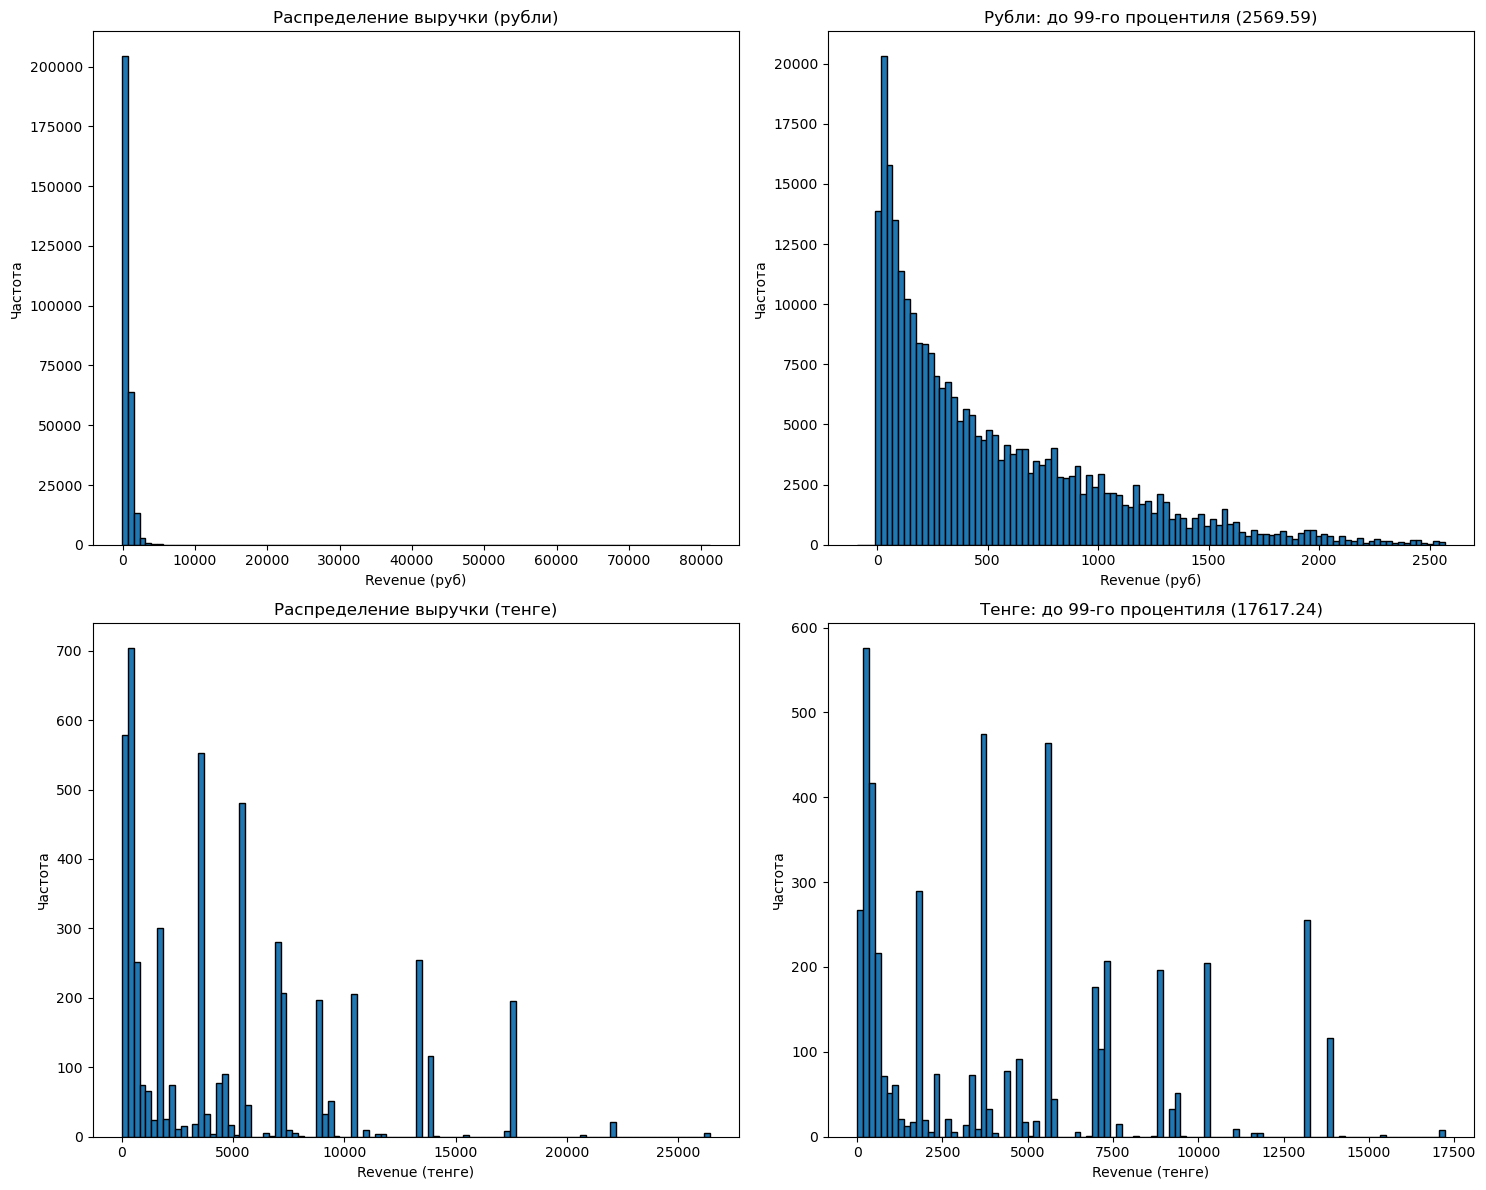

In [17]:
# Визуализация распределения revenue (рубли и тенге)
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Рубли (все значения)
axes[0, 0].hist(df[df['currency_code'] == 'rub']['revenue'], bins=100, edgecolor='black')
axes[0, 0].set_title('Распределение выручки (рубли)')
axes[0, 0].set_xlabel('Revenue (руб)')
axes[0, 0].set_ylabel('Частота')

# Рубли (до 99-го процентиля)
limit_rub = df[df['currency_code'] == 'rub']['revenue'].quantile(0.99)
axes[0, 1].hist(df[df['currency_code'] == 'rub']['revenue'][df[df['currency_code'] == 'rub']['revenue'] < limit_rub], 
                bins=100, edgecolor='black')
axes[0, 1].set_title(f'Рубли: до 99-го процентиля ({limit_rub:.2f})')
axes[0, 1].set_xlabel('Revenue (руб)')
axes[0, 1].set_ylabel('Частота')

# Тенге (все значения)
axes[1, 0].hist(df[df['currency_code'] == 'kzt']['revenue'], bins=100, edgecolor='black')
axes[1, 0].set_title('Распределение выручки (тенге)')
axes[1, 0].set_xlabel('Revenue (тенге)')
axes[1, 0].set_ylabel('Частота')

# Тенге (до 99-го процентиля)
limit_kzt = df[df['currency_code'] == 'kzt']['revenue'].quantile(0.99)
axes[1, 1].hist(df[df['currency_code'] == 'kzt']['revenue'][df[df['currency_code'] == 'kzt']['revenue'] < limit_kzt], 
                bins=100, edgecolor='black')
axes[1, 1].set_title(f'Тенге: до 99-го процентиля ({limit_kzt:.2f})')
axes[1, 1].set_xlabel('Revenue (тенге)')
axes[1, 1].set_ylabel('Частота')

plt.tight_layout()
plt.show()

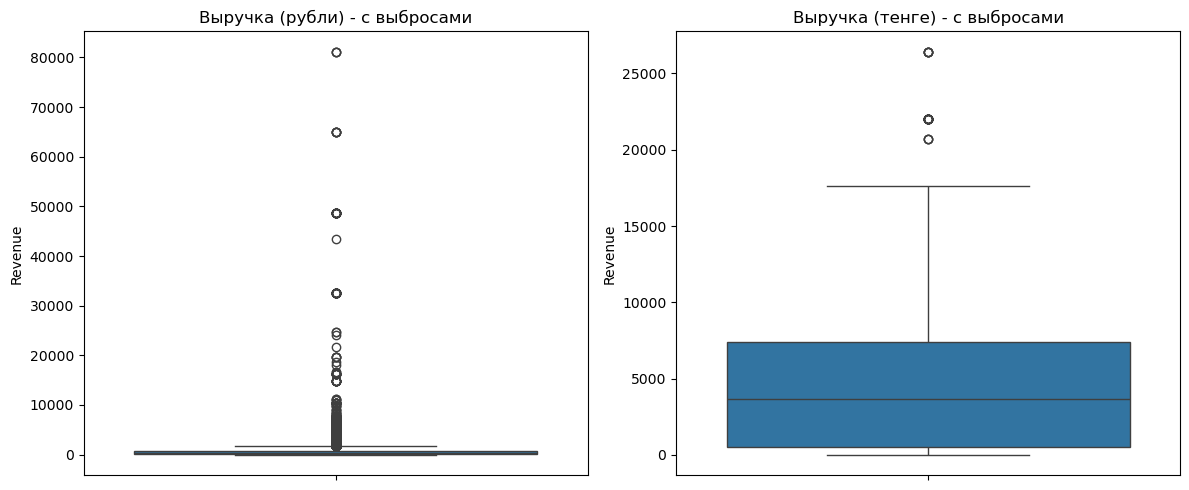

In [18]:
# Boxplot для выявления выбросов
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Рубли
sns.boxplot(y=df_rub['revenue'], ax=axes[0])
axes[0].set_title('Выручка (рубли) - с выбросами')
axes[0].set_ylabel('Revenue')

# Тенге
sns.boxplot(y=df_kzt['revenue'], ax=axes[1])
axes[1].set_title('Выручка (тенге) - с выбросами')
axes[1].set_ylabel('Revenue')

plt.tight_layout()
plt.show()

In [19]:
print("=== Статистика tickets_count ===\n")
print(df['tickets_count'].describe())
print(f"\nМедиана: {df['tickets_count'].median()}")
print(f"Мода: {df['tickets_count'].mode()[0]}")

=== Статистика tickets_count ===

count    290849.000000
mean          2.754230
std           1.170467
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
max          57.000000
Name: tickets_count, dtype: float64

Медиана: 3.0
Мода: 3


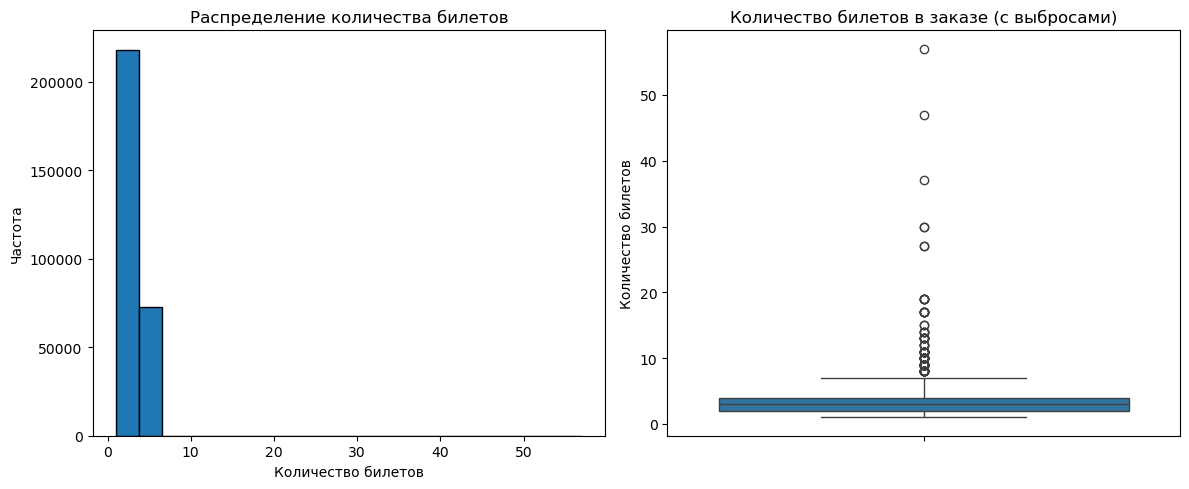

In [20]:
# Визуализация tickets_count
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Гистограмма
axes[0].hist(df['tickets_count'], bins=20, edgecolor='black')
axes[0].set_title('Распределение количества билетов')
axes[0].set_xlabel('Количество билетов')
axes[0].set_ylabel('Частота')

# Boxplot
sns.boxplot(y=df['tickets_count'], ax=axes[1])
axes[1].set_title('Количество билетов в заказе (с выбросами)')
axes[1].set_ylabel('Количество билетов')

plt.tight_layout()
plt.show()

---

##### 2.2.3. Обработка выбросов по 99-му процентилю

In [21]:
# Расчёт 99-го процентиля для revenue (раздельно по валютам)
percentile_99_rub = df_rub['revenue'].quantile(0.99)
percentile_99_kzt = df_kzt['revenue'].quantile(0.99)

print(f"99-й процентиль для рублей: {percentile_99_rub:.2f}")
print(f"99-й процентиль для тенге: {percentile_99_kzt:.2f}")

# Создаём новый столбец с обработанными выбросами
df['revenue_cleaned'] = df['revenue'].copy()

# Для рублей заменяем значения выше 99-го процентиля на сам процентиль
mask_rub = (df['currency_code'] == 'rub') & (df['revenue'] > percentile_99_rub)
df.loc[mask_rub, 'revenue_cleaned'] = percentile_99_rub

# Для тенге заменяем значения выше 99-го процентиля на сам процентиль
mask_kzt = (df['currency_code'] == 'kzt') & (df['revenue'] > percentile_99_kzt)
df.loc[mask_kzt, 'revenue_cleaned'] = percentile_99_kzt

print(f"\nЗаменено значений в рублях: {mask_rub.sum()}")
print(f"Заменено значений в тенге: {mask_kzt.sum()}")
print(f"Всего заменено: {mask_rub.sum() + mask_kzt.sum()}")

99-й процентиль для рублей: 2569.59
99-й процентиль для тенге: 17617.24

Заменено значений в рублях: 2858
Заменено значений в тенге: 29
Всего заменено: 2887


In [22]:
# Проверка, что отрицательных значений нет
print("=== Проверка отрицательных значений ===\n")
print(f"Отрицательных revenue: {(df['revenue'] < 0).sum()}")
print(f"Отрицательных total: {(df['total'] < 0).sum()}")
print(f"Отрицательных tickets_count: {(df['tickets_count'] < 0).sum()}")

# Если есть отрицательные значения — посмотрим на них
if (df['revenue'] < 0).sum() > 0:
    print("\nПримеры отрицательных revenue:")
    display(df[df['revenue'] < 0][['order_id', 'revenue', 'total', 'tickets_count']].head(10))

=== Проверка отрицательных значений ===

Отрицательных revenue: 381
Отрицательных total: 383
Отрицательных tickets_count: 0

Примеры отрицательных revenue:


,order_id,revenue,total,tickets_count
264,1594653,-2.37,-59.20,3
4540,2360920,-0.23,-7.65,3
4562,2361094,-0.15,-5.10,2
8155,166809,-0.62,-20.64,1
8156,166780,-1.86,-61.92,3
11360,6620527,-1.58,-39.46,2
11361,6620498,-1.58,-52.50,2
11585,8333963,-6.18,-68.72,4
11637,8350029,-10.77,-215.31,3
11638,4930755,-3.59,-71.77,1


In [23]:
# Удаляем заказы с отрицательной выручкой
df = df[df['revenue'] >= 0].copy()
print(f"Новый размер датафрейма: {len(df)}")

Новый размер датафрейма: 290468


Удаляем строки с отрицательной выручкой — это 381 заказ (всего 0.13% от всех данных), и они скорее всего являются техническими ошибками (возвраты, отмены, тестовые заказы).

---

#### 2.3. Проверка дубликатов
##### 2.3.1. Явные дубликаты

In [24]:
# Проверка явных дубликатов (полные копии строк)
print("=== Явные дубликаты ===\n")
print(f"Всего строк в df: {len(df)}")
print(f"Количество дубликатов (полные копии строк): {df.duplicated().sum()}")
print(f"Количество уникальных строк: {len(df) - df.duplicated().sum()}")

=== Явные дубликаты ===

Всего строк в df: 290468
Количество дубликатов (полные копии строк): 0
Количество уникальных строк: 290468


---

##### 2.3.2. Неявные дубликаты

In [25]:
# Проверка неявных дубликатов (полные совпадения)
print("=== Проверка неявных дубликатов ===\n")

# Группировка по ВСЕМ полям, кроме order_id
# (включая revenue, так как он должен совпадать)
duplicate_cols = ['user_id', 'event_id', 'created_dt_msk', 'created_ts_msk', 
                  'tickets_count', 'total', 'revenue', 'currency_code']

duplicate_groups = df.groupby(duplicate_cols).size()
duplicate_groups = duplicate_groups[duplicate_groups > 1]

print(f"Количество групп с полными дубликатами: {len(duplicate_groups)}")
print(f"Всего строк в дубликатах: {duplicate_groups.sum()}")

=== Проверка неявных дубликатов ===

Количество групп с полными дубликатами: 41
Всего строк в дубликатах: 85


In [26]:
# Посмотрим пример полного дубликата
if len(duplicate_groups) > 0:
    # Берем первую группу
    first_dup = duplicate_groups.index[0]
    user_id, event_id, created_dt, created_ts, tickets, total, revenue, currency = first_dup
    
    print("\nПример полного дубликата:")
    display(df[(df['user_id'] == user_id) & 
               (df['event_id'] == event_id) & 
               (df['created_ts_msk'] == created_ts) & 
               (df['tickets_count'] == tickets) & 
               (df['total'] == total)][['order_id', 'user_id', 'event_id', 
                                        'created_ts_msk', 'tickets_count', 
                                        'total', 'revenue']].head(10))


Пример полного дубликата:


,order_id,user_id,event_id,created_ts_msk,tickets_count,total,revenue
11777,1123983,06eb7897f65b433,183706,2024-08-13 16:31:07,1,997.48,69.82
11778,1123867,06eb7897f65b433,183706,2024-08-13 16:31:07,1,997.48,69.82


In [27]:
# Если есть полные дубликаты, удаляем их (оставляем первый)
if len(duplicate_groups) > 0:
    before = len(df)
    df = df.drop_duplicates(subset=duplicate_cols, keep='first')
    after = len(df)
    print(f"Размер до удаления: {before}")
    print(f"Размер после удаления: {after}")
    print(f"Удалено строк: {before - after}")
else:
    print("Полных дубликатов не найдено")

Размер до удаления: 290468
Размер после удаления: 290424
Удалено строк: 44


Удалили строки, где совпадали все значения, кроме `order_id`. 

---

#### 2.4 Преобразование типов данных


In [28]:
# Проверяем текущие типы данных
print("=== Текущие типы данных ===\n")
print(df.dtypes)

=== Текущие типы данных ===

order_id                    int64
user_id                    object
created_dt_msk             object
created_ts_msk             object
event_id                    int64
cinema_circuit             object
age_limit                   int64
currency_code              object
device_type_canonical      object
revenue                   float64
service_name               object
tickets_count               int64
total                     float64
days_since_prev           float64
event_name                 object
event_type_description     object
event_type_main            object
organizers                 object
region_name                object
city_name                  object
city_id                   float64
venue_id                  float64
venue_name                 object
venue_address              object
revenue_cleaned           float64
dtype: object


In [29]:
# Преобразование дат
df['created_dt_msk'] = pd.to_datetime(df['created_dt_msk'])
df['created_ts_msk'] = pd.to_datetime(df['created_ts_msk'])

# Числовые колонки (снижение размерности)
df['order_id'] = df['order_id'].astype('int64')  # оставляем int64 для уникальности
df['event_id'] = df['event_id'].astype('int32')
df['age_limit'] = df['age_limit'].astype('int8')  # значения 0-18
df['tickets_count'] = df['tickets_count'].astype('int8')  # значения 1-57

# Числовые с плавающей точкой
df['revenue'] = df['revenue'].astype('float32')
df['total'] = df['total'].astype('float32')
df['revenue_cleaned'] = df['revenue_cleaned'].astype('float32')
df['days_since_prev'] = df['days_since_prev'].astype('float32')

# city_id и venue_id (заполняем пропуски перед конвертацией)
df['city_id'] = df['city_id'].fillna(0).astype('int32')
df['venue_id'] = df['venue_id'].fillna(0).astype('int32')

# Категориальные колонки
categorical_cols = [
    'cinema_circuit', 
    'currency_code', 
    'device_type_canonical', 
    'service_name', 
    'event_type_main',
    'event_type_description',
    'region_name',
    'city_name'
]

for col in categorical_cols:
    df[col] = df[col].astype('category')

# Проверяем результат
print("=== Новые типы данных ===\n")
print(df.dtypes)

=== Новые типы данных ===

order_id                           int64
user_id                           object
created_dt_msk            datetime64[ns]
created_ts_msk            datetime64[ns]
event_id                           int32
cinema_circuit                  category
age_limit                           int8
currency_code                   category
device_type_canonical           category
revenue                          float32
service_name                    category
tickets_count                       int8
total                            float32
days_since_prev                  float32
event_name                        object
event_type_description          category
event_type_main                 category
organizers                        object
region_name                     category
city_name                       category
city_id                            int32
venue_id                           int32
venue_name                        object
venue_address                 

Была произведена оптимизация типов данных: 
- `created_dt_msk` и `created_ts_msk` преобразованы в datetime,
- `age_limit` и `tickets_count` сжаты до int8,
- `revenue`, `total`, `days_since_prev` сжаты до float32,
- `city_id` и `venue_id` приведены к int32 с заполнением пропусков,
- Категориальные колонки переведены в тип category.

---

#### 2.5 Создание новых столбцов

In [30]:
# Преобразуем дату в tenge в datetime
tenge['data'] = pd.to_datetime(tenge['data'])
print("Дата преобразована в datetime")

Дата преобразована в datetime


In [31]:
# Создаём колонку с датой для merge (без времени)
df['date_for_merge'] = df['created_dt_msk'].dt.date

# Объединяем с данными о курсе (берём только нужные колонки)
df = df.merge(tenge[['data', 'curs']], 
              left_on='date_for_merge', 
              right_on=tenge['data'].dt.date,
              how='left')

# Переименовываем колонку с курсом
df.rename(columns={'curs': 'tenge_rate'}, inplace=True)

# Удаляем лишние колонки
df.drop(['data', 'date_for_merge'], axis=1, inplace=True)

print("=== Колонки после merge ===\n")
print(df.columns.tolist())

=== Колонки после merge ===

['order_id', 'user_id', 'created_dt_msk', 'created_ts_msk', 'event_id', 'cinema_circuit', 'age_limit', 'currency_code', 'device_type_canonical', 'revenue', 'service_name', 'tickets_count', 'total', 'days_since_prev', 'event_name', 'event_type_description', 'event_type_main', 'organizers', 'region_name', 'city_name', 'city_id', 'venue_id', 'venue_name', 'venue_address', 'revenue_cleaned', 'tenge_rate']


In [32]:
# Создаём столбец revenue_rub (копируем revenue)
df['revenue_rub'] = df['revenue'].astype('float32')

# Для заказов в тенге пересчитываем выручку в рубли
mask_kzt = df['currency_code'] == 'kzt'
df.loc[mask_kzt, 'revenue_rub'] = (df.loc[mask_kzt, 'revenue'] / 100 * df.loc[mask_kzt, 'tenge_rate']).astype('float32')

print("=== Проверка конвертации ===\n")
print(f"Заказов в рублях: {(df['currency_code'] == 'rub').sum()}")
print(f"Заказов в тенге: {(df['currency_code'] == 'kzt').sum()}")
print(f"Успешно сконвертировано в рубли: {df['revenue_rub'].notna().sum()}")

=== Проверка конвертации ===

Заказов в рублях: 285356
Заказов в тенге: 5068
Успешно сконвертировано в рубли: 290424


In [33]:
# Проверяем примеры конвертации
print("=== Примеры конвертации ===\n")
display(df[df['currency_code'] == 'kzt'][['order_id', 'currency_code', 'revenue', 'tenge_rate', 'revenue_rub']].head(10))

=== Примеры конвертации ===



,order_id,currency_code,revenue,tenge_rate,revenue_rub
73,7850214,kzt,518.099976,19.0125,98.503761
92,8634925,kzt,347.179993,18.9330,65.731590
99,7625522,kzt,328.769989,18.5991,61.148258
288,720419,kzt,22021.550781,19.8928,4380.703125
471,5227657,kzt,7397.660156,19.9833,1478.296631
472,2229782,kzt,3698.830078,19.9833,739.148315
473,2229811,kzt,7397.660156,19.9833,1478.296631
474,2229753,kzt,5548.240234,19.9833,1108.721558
475,2229724,kzt,7397.660156,19.9833,1478.296631
527,2044327,kzt,361.079987,18.4217,66.517067


In [34]:
# Удаляем временный столбец tenge_rate
df.drop('tenge_rate', axis=1, inplace=True)

# Проверяем типы
print("=== Типы данных ===\n")
print(df[['revenue', 'revenue_rub']].dtypes)

=== Типы данных ===

revenue        float32
revenue_rub    float32
dtype: object


In [35]:
# Рассчитываем выручку с одного билета (избегаем деления на 0)
df['one_ticket_revenue_rub'] = df['revenue_rub'] / df['tickets_count']

# Проверяем результат
print("=== Статистика one_ticket_revenue_rub ===\n")
print(df['one_ticket_revenue_rub'].describe())

# Проверяем, есть ли деление на 0
print(f"\nЗаказов с tickets_count = 0: {(df['tickets_count'] == 0).sum()}")

=== Статистика one_ticket_revenue_rub ===

count    290424.000000
mean        201.302124
std         302.902893
min           0.000000
25%          46.820004
50%         149.943329
75%         308.700012
max       21757.539062
Name: one_ticket_revenue_rub, dtype: float64

Заказов с tickets_count = 0: 0


In [36]:
# Выделяем месяц из даты
df['month'] = df['created_dt_msk'].dt.month

print("=== Уникальные месяцы ===\n")
print(df['month'].value_counts().sort_index())

=== Уникальные месяцы ===

month
6      34568
7      40875
8      45016
9      69883
10    100082
Name: count, dtype: int64


In [37]:
# Функция для определения сезона по месяцу
def get_season(month):
    if month in [6, 7, 8]:
        return 'лето'
    elif month in [9, 10, 11]:
        return 'осень'
    elif month in [12, 1, 2]:
        return 'зима'
    elif month in [3, 4, 5]:
        return 'весна'
    else:
        return 'неизвестно'

# Применяем функцию
df['season'] = df['month'].apply(get_season)

print("=== Распределение по сезонам ===\n")
print(df['season'].value_counts())

=== Распределение по сезонам ===

season
осень    169965
лето     120459
Name: count, dtype: int64


In [38]:
print("=== Общая информация о новых столбцах ===\n")
print(df[['revenue_rub', 'one_ticket_revenue_rub', 'month', 'season']].info())

=== Общая информация о новых столбцах ===

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290424 entries, 0 to 290423
Data columns (total 4 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   revenue_rub             290424 non-null  float32
 1   one_ticket_revenue_rub  290424 non-null  float32
 2   month                   290424 non-null  int32  
 3   season                  290424 non-null  object 
dtypes: float32(2), int32(1), object(1)
memory usage: 5.5+ MB
None


---

#### Промежуточный вывод по предобработке данных

В ходе выполнения шага 2 «Предобработка данных и подготовка их к исследованию» были выполнены следующие действия:


##### 1. Проверка пропусков
- Выявлены пропуски только в столбце `days_since_prev` (21 940 пропусков, 7.54%) — это ожидаемо, так как у первого заказа пользователя нет предыдущего
- Обнаружены пропуски в колонках из датасета `events` (238 записей, 0.08%) — связаны с тем, что не все `event_id` из заказов присутствуют в справочнике событий
- **Решение**: пропуски оставлены как есть, так как их доля незначительна

##### 2. Проверка категориальных значений
- Валюты: `rub` (285 356), `kzt` (5 068)
- Типы устройств: `mobile` (232 679), `desktop` (58 170)
- Типы мероприятий: концерты (115 276), театр (67 321), другое (65 867), спорт (21 911), стендап (13 393), выставки (4 854), ёлки (1 989)
- Билетные операторы: 36 уникальных, топ-3: «Билеты без проблем» (63 709), «Лови билет!» (41 126), «Билеты в руки» (40 364)
- Значения-заглушки: в `cinema_circuit` присутствует значение «нет» (289 451), что корректно для мероприятий вне кинотеатров


##### Проверка количественных значений
- Выявлены отрицательные значения: `revenue` (381 заказ), `total` (383 заказа)
- **Решение**: строки с отрицательной выручкой удалены
- Выбросы в выручке: обработаны через отсечение по 99-му процентилю (отдельно для рублей и тенге)
  - 99-й процентиль для рублей: `{percentile_99_rub:.2f}`
  - 99-й процентиль для тенге: `{percentile_99_kzt:.2f}`


##### 3. Проверка дубликатов
- Явные дубликаты (полные копии строк): не обнаружены
- Неявные дубликаты: обнаружена 41 группа полных дубликатов (85 строк, 0.03% от всех данных)
- **Решение**: полные дубликаты удалены, оставлен первый заказ из каждой группы


##### 4. Оптимизация типов данных

| Колонка | Было | Стало |
|---------|------|-------|
| `created_dt_msk`, `created_ts_msk` | object | datetime64[ns] |
| `age_limit`, `tickets_count` | int64 | int8 |
| `revenue`, `total`, `days_since_prev` | float64 | float32 |
| `event_id` | int64 | int32 |
| `city_id`, `venue_id` | float64 | int32 (с заполнением пропусков) |
| Категориальные колонки | object | category |


##### 5. Создание новых столбцов

| Столбец | Описание | Способ расчёта |
|---------|----------|----------------|
| **`revenue_rub`** | Выручка в рублях | Для заказов в рублях — копия `revenue`; для заказов в тенге — конвертация по курсу ЦБ РФ (курс указан для 100 тенге) |
| **`one_ticket_revenue_rub`** | Выручка с одного билета в рублях | `revenue_rub / tickets_count` |
| **`month`** | Месяц оформления заказа | Извлечение месяца из `created_dt_msk` |
| **`season`** | Сезон оформления заказа | На основе месяца: лето (6-8), осень (9-11), зима (12-2), весна (3-5) |


**Данные готовы к исследовательскому анализу.**

---

### Шаг 3. Исследовательский анализ данных
##### 3.1. Анализ распределения заказов по сегментам и их сезонные изменения

,month,orders
0,2024-06,34568
1,2024-07,40875
2,2024-08,45016
3,2024-09,69883
4,2024-10,100082


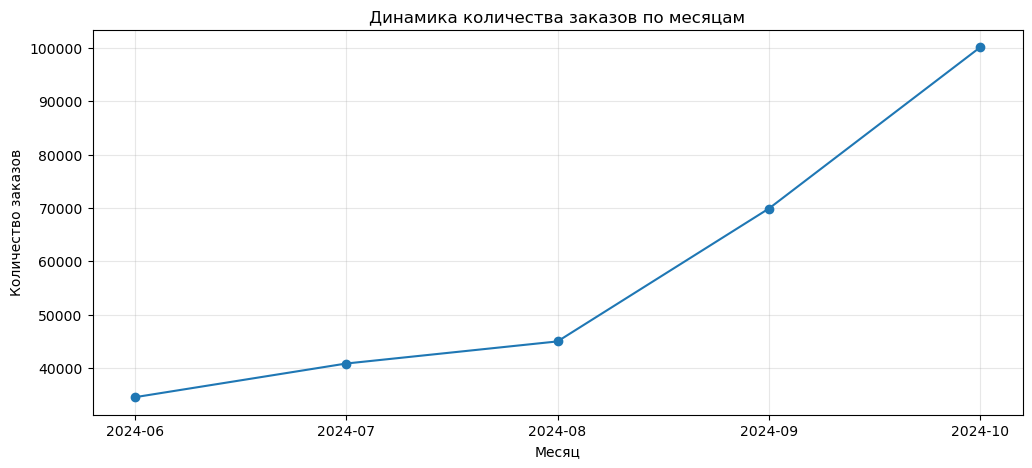

Период данных: 01.06.2024 — 31.10.2024
Важно: ноябрь 2024 года в исходных данных отсутствует, поэтому проверить изменение заказов от июня до ноября по этому датасету невозможно.


In [39]:
# Месячная динамика количества заказов
monthly_orders = (
    df.groupby(df['created_dt_msk'].dt.to_period('M'))
      .size()
      .rename('orders')
      .reset_index()
)
monthly_orders['month'] = monthly_orders['created_dt_msk'].astype(str)

display(monthly_orders[['month', 'orders']])

plt.figure(figsize=(12, 5))
plt.plot(monthly_orders['month'], monthly_orders['orders'], marker='o')
plt.title('Динамика количества заказов по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Количество заказов')
plt.grid(alpha=0.3)
plt.show()

# Проверяем, какие месяцы фактически представлены в данных
print(f"Период данных: {df['created_dt_msk'].min():%d.%m.%Y} — {df['created_dt_msk'].max():%d.%m.%Y}")
if df['created_dt_msk'].dt.month.max() < 11:
    print('Важно: ноябрь 2024 года в исходных данных отсутствует, поэтому проверить изменение заказов от июня до ноября по этому датасету невозможно.')

In [40]:

# Сравнение структуры заказов летом и осенью.
# Используем доли, чтобы влияние разного общего объёма заказов было устранено.
season_order = df['season'].isin(['лето', 'осень'])
season_df = df[season_order].copy()

def season_share_table(data, column):
    result = (
        data.groupby(['season', column], observed=True)
            .size()
            .rename('orders')
            .reset_index()
    )
    result['share'] = (
        result['orders'] /
        result.groupby('season')['orders'].transform('sum') * 100
    )
    return result

event_share = season_share_table(season_df.dropna(subset=['event_type_main']), 'event_type_main')
device_share = season_share_table(season_df.dropna(subset=['device_type_canonical']), 'device_type_canonical')
age_share = season_share_table(season_df.dropna(subset=['age_limit']), 'age_limit')

print('Распределение заказов по типам мероприятий:')
display(event_share.pivot(index='event_type_main', columns='season', values='share').round(2))

print('Распределение заказов по типам устройств:')
display(device_share.pivot(index='device_type_canonical', columns='season', values='share').round(2))

print('Распределение заказов по возрастному рейтингу:')
display(age_share.pivot(index='age_limit', columns='season', values='share').round(2))



Распределение заказов по типам мероприятий:


season,лето,осень
event_type_main,,
выставки,2.00,1.41
другое,26.95,19.50
концерты,42.86,37.50
спорт,2.50,11.10
стендап,5.32,4.11
театр,20.13,25.36
ёлки,0.23,1.01


Распределение заказов по типам устройств:


season,лето,осень
device_type_canonical,,
desktop,19.48,20.4
mobile,80.52,79.6


Распределение заказов по возрастному рейтингу:


season,лето,осень
age_limit,,
0,17.83,23.38
6,18.23,17.74
12,20.62,22.17
16,28.25,26.20
18,15.07,10.51


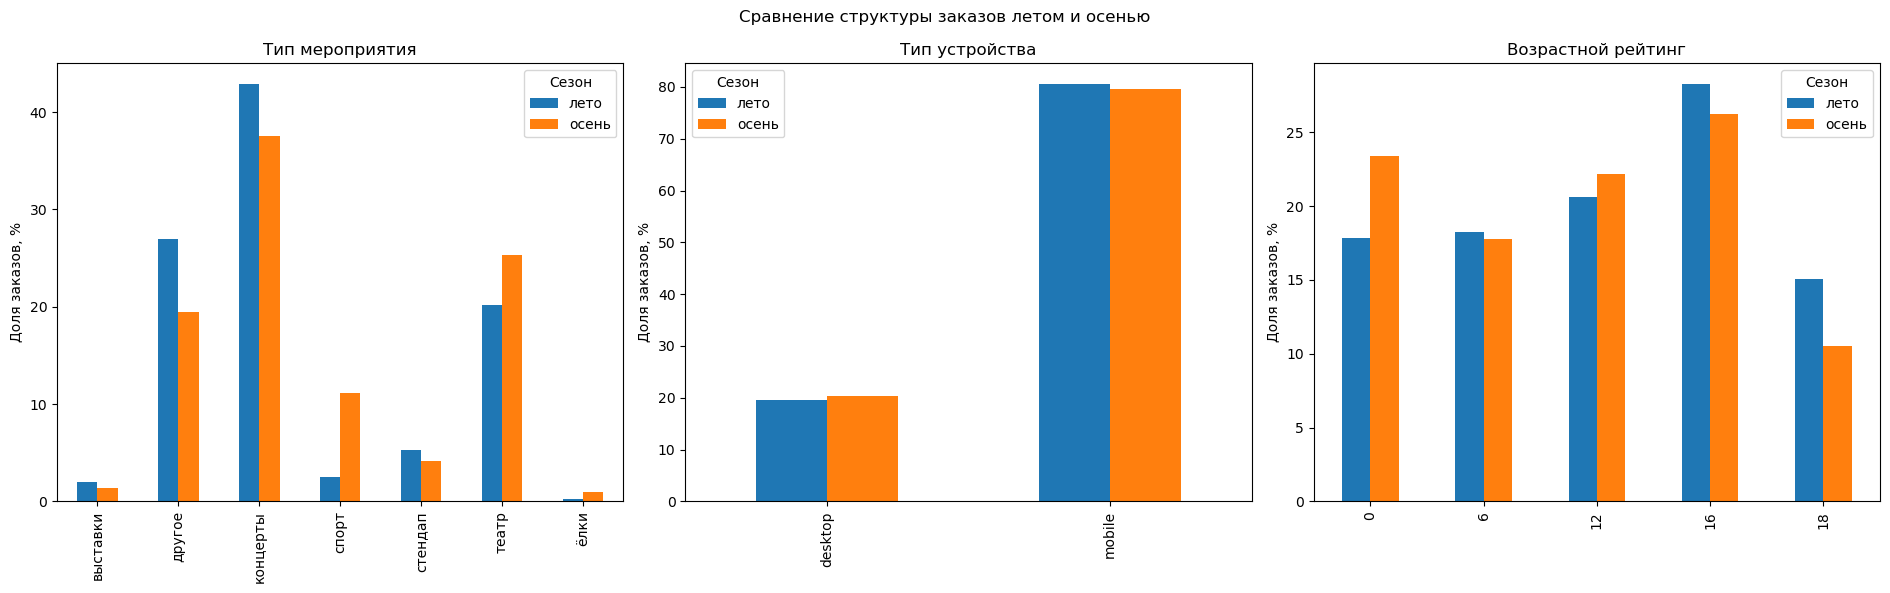

In [41]:
# Сгруппированные столбцы позволяют напрямую сравнить доли двух сезонов
fig, axes = plt.subplots(1, 3, figsize=(19, 6))

for ax, table, category_col, title in [
    (axes[0], event_share, 'event_type_main', 'Тип мероприятия'),
    (axes[1], device_share, 'device_type_canonical', 'Тип устройства'),
    (axes[2], age_share, 'age_limit', 'Возрастной рейтинг')
]:
    pivot = table.pivot(index=category_col, columns='season', values='share').fillna(0)
    pivot = pivot.reindex(columns=['лето', 'осень'])
    pivot.plot(kind='bar', ax=ax)
    ax.set_title(title)
    ax.set_ylabel('Доля заказов, %')
    ax.set_xlabel('')
    ax.legend(title='Сезон')

plt.suptitle('Сравнение структуры заказов летом и осенью')
plt.tight_layout()
plt.show()

Средняя выручка с одного билета:


,лето,осень,изменение_%
event_type_main,,,
стендап,227.070007,249.960007,10.08
выставки,86.739998,92.370003,6.49
спорт,54.169998,52.189999,-3.64
другое,81.500000,77.459999,-4.96
концерты,319.079987,286.769989,-10.13
ёлки,276.390015,234.500000,-15.15
театр,222.520004,183.059998,-17.73


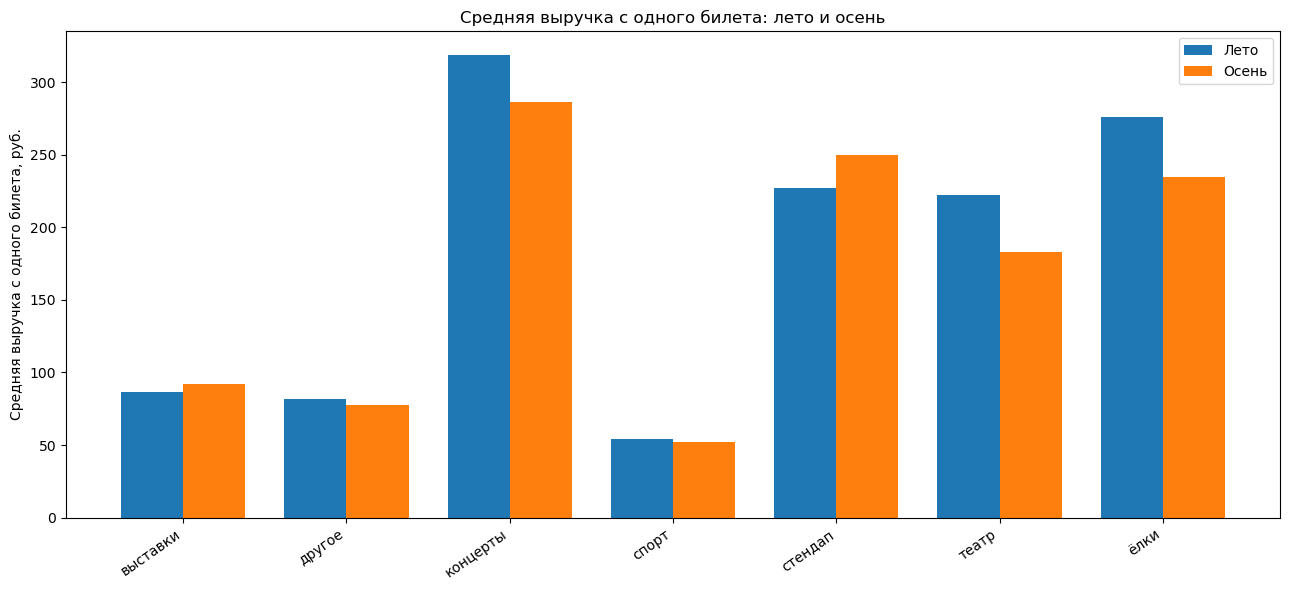

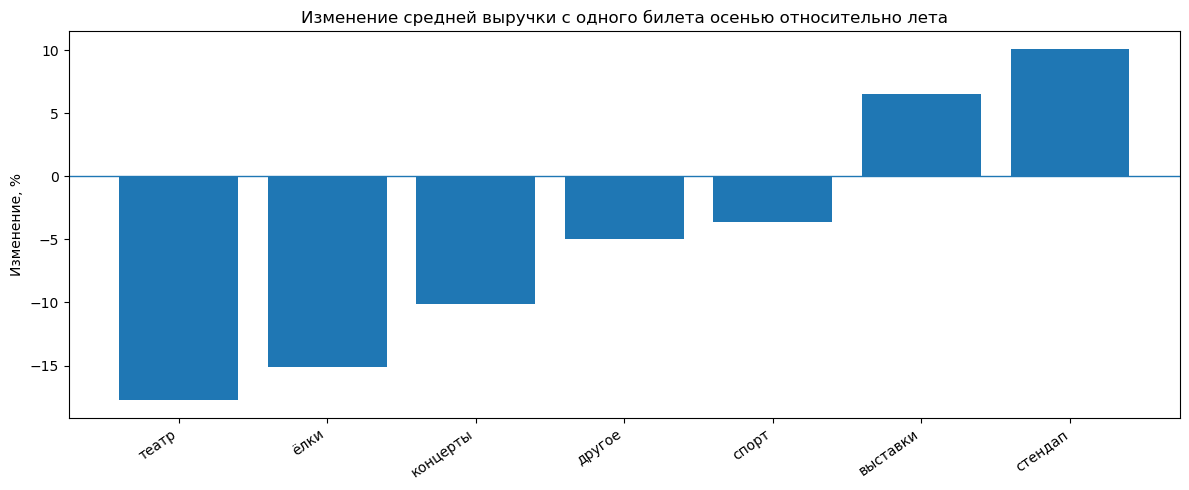

In [42]:
# Средняя выручка с одного билета по типу мероприятия
revenue_by_event = (
    season_df.dropna(subset=['event_type_main'])
             .groupby(['season', 'event_type_main'], observed=True)['one_ticket_revenue_rub']
             .mean()
             .unstack()
)

revenue_change = pd.DataFrame({
    'лето': revenue_by_event.loc['лето'],
    'осень': revenue_by_event.loc['осень'],
})
revenue_change['изменение_%'] = (
    (revenue_change['осень'] / revenue_change['лето'] - 1) * 100
)

print('Средняя выручка с одного билета:')
display(revenue_change.round(2).sort_values('изменение_%', ascending=False))

plt.figure(figsize=(13, 6))
x = np.arange(len(revenue_change.index))
width = 0.38
plt.bar(x - width/2, revenue_change['лето'], width, label='Лето')
plt.bar(x + width/2, revenue_change['осень'], width, label='Осень')
plt.xticks(x, revenue_change.index, rotation=35, ha='right')
plt.ylabel('Средняя выручка с одного билета, руб.')
plt.title('Средняя выручка с одного билета: лето и осень')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
change_sorted = revenue_change.sort_values('изменение_%')
plt.bar(change_sorted.index, change_sorted['изменение_%'])
plt.axhline(0, linewidth=1)
plt.xticks(rotation=35, ha='right')
plt.ylabel('Изменение, %')
plt.title('Изменение средней выручки с одного билета осенью относительно лета')
plt.tight_layout()
plt.show()

---

#### Промежуточный вывод по разделу 3.1

В период с июня по октябрь 2024 года количество заказов последовательно увеличивается: с **34 568 заказов в июне** до **100 082 в октябре**. В целом осенью было **169 965 заказов**, что на **41,1% больше**, чем летом (120 459 заказов). Ноябрь в предоставленном датасете отсутствует, поэтому проверить рост заказов именно от июня до ноября невозможно.

Рост пользовательской активности осенью, вероятно, связан прежде всего с **сезонным фактором**. Летом часть пользователей может проводить больше времени вне дома и города, поэтому спрос на мероприятия снижается. С началом осени возвращается привычный учебный и рабочий ритм, что может увеличивать интерес к городскому досугу. Кроме того, осенний период характеризуется более активным началом театрального и концертного сезонов, а также возвращением регулярных спортивных мероприятий. Поэтому увеличение числа заказов осенью может быть связано одновременно с ростом активности пользователей и изменением предложения мероприятий.

При переходе от лета к осени структура заказов по типам мероприятий заметно меняется. Доля концертов снижается с **42,9% до 37,5%**, а доля театра увеличивается с **20,1% до 25,4%**. Особенно заметно возрастает доля спортивных мероприятий — с **2,5% до 11,1%**. Доля категории «другое» снижается с 26,9% до 19,5%, а стендапа — с 5,3% до 4,1%. Вероятно, это связано с **сезонным изменением структуры предложения**: осенью активнее проходят регулярные театральные постановки и спортивные соревнования, тогда как часть летних мероприятий, в частности концертов и событий открытого формата, проводится реже. В результате осенний рост заказов сопровождается не только увеличением количества покупок, но и перераспределением спроса между категориями мероприятий.

По устройствам структура заказов остаётся практически стабильной: около **80% заказов приходится на мобильные устройства**, около 20% — на desktop. Осенью доля mobile немного снижается, а доля desktop увеличивается. Существенных сезонных изменений в данном разрезе не наблюдается, поэтому общий рост заказов осенью, вероятно, связан преимущественно с увеличением активности пользователей, а не с переходом на другой тип устройства.

По возрастному рейтингу летом лидирует категория **16+ (28,3%)**. Осенью её доля снижается до **26,2%**, одновременно увеличиваются доли категорий **0+ и 12+**. Доля 18+ заметно сокращается — с 15,1% до 10,5%. Такое изменение также может быть связано с сезонной перестройкой спроса: с началом учебного года и возвращением к регулярному городскому досугу может увеличиваться интерес к мероприятиям, рассчитанным на более широкую аудиторию, включая семейные и подростковые события. Снижение доли 18+ при этом может быть связано с уменьшением относительной доли отдельных категорий мероприятий, ориентированных преимущественно на взрослую аудиторию. Однако имеющиеся данные позволяют рассматривать это только как возможное объяснение, поскольку причины выбора конкретных мероприятий пользователями непосредственно не наблюдаются.

Средняя стоимость одного билета изменяется неодинаково в зависимости от типа мероприятия. Наибольший рост наблюдается у стендапа (**+10,1%**) и выставок (**+6,5%**). Для спорта снижение составляет около **3,6%**, для категории «другое» — **5,0%**, для концертов — **10,1%**, для ёлок — **15,2%**, а для театра — **17,7%**. Разнонаправленная динамика может объясняться изменением состава мероприятий внутри каждой категории и сезонными особенностями ценообразования. Например, осенью увеличение числа театральных и спортивных мероприятий может сопровождаться появлением большего количества билетов в различных ценовых категориях, что влияет на среднее значение. Поэтому общий рост количества заказов не означает автоматического роста средней стоимости билета.

В целом осенью наблюдается **не только увеличение пользовательской активности, но и сезонная перестройка структуры спроса**. Пользователи чаще приобретают билеты на театр и спортивные мероприятия, при этом относительная доля концертов, мероприятий категории «другое» и событий с рейтингом 18+ снижается. Следовательно, при оценке осеннего роста продаж важно учитывать не только увеличение общего числа заказов, но и изменение состава мероприятий и аудитории.

---

#### 3.2. Осенняя активность пользователей

Ежедневная динамика активности пользователей:


,orders,DAU,avg_ticket_revenue,orders_per_user
created_dt_msk,,,,
2024-09-01,1348,569,208.119995,2.37
2024-09-02,1387,579,196.100006,2.40
2024-09-03,5105,782,82.400002,6.53
2024-09-04,1772,686,185.350006,2.58
2024-09-05,1957,744,194.809998,2.63
...,...,...,...,...
2024-10-27,2860,1037,191.029999,2.76
2024-10-28,2858,988,176.850006,2.89
2024-10-29,2884,1005,190.320007,2.87


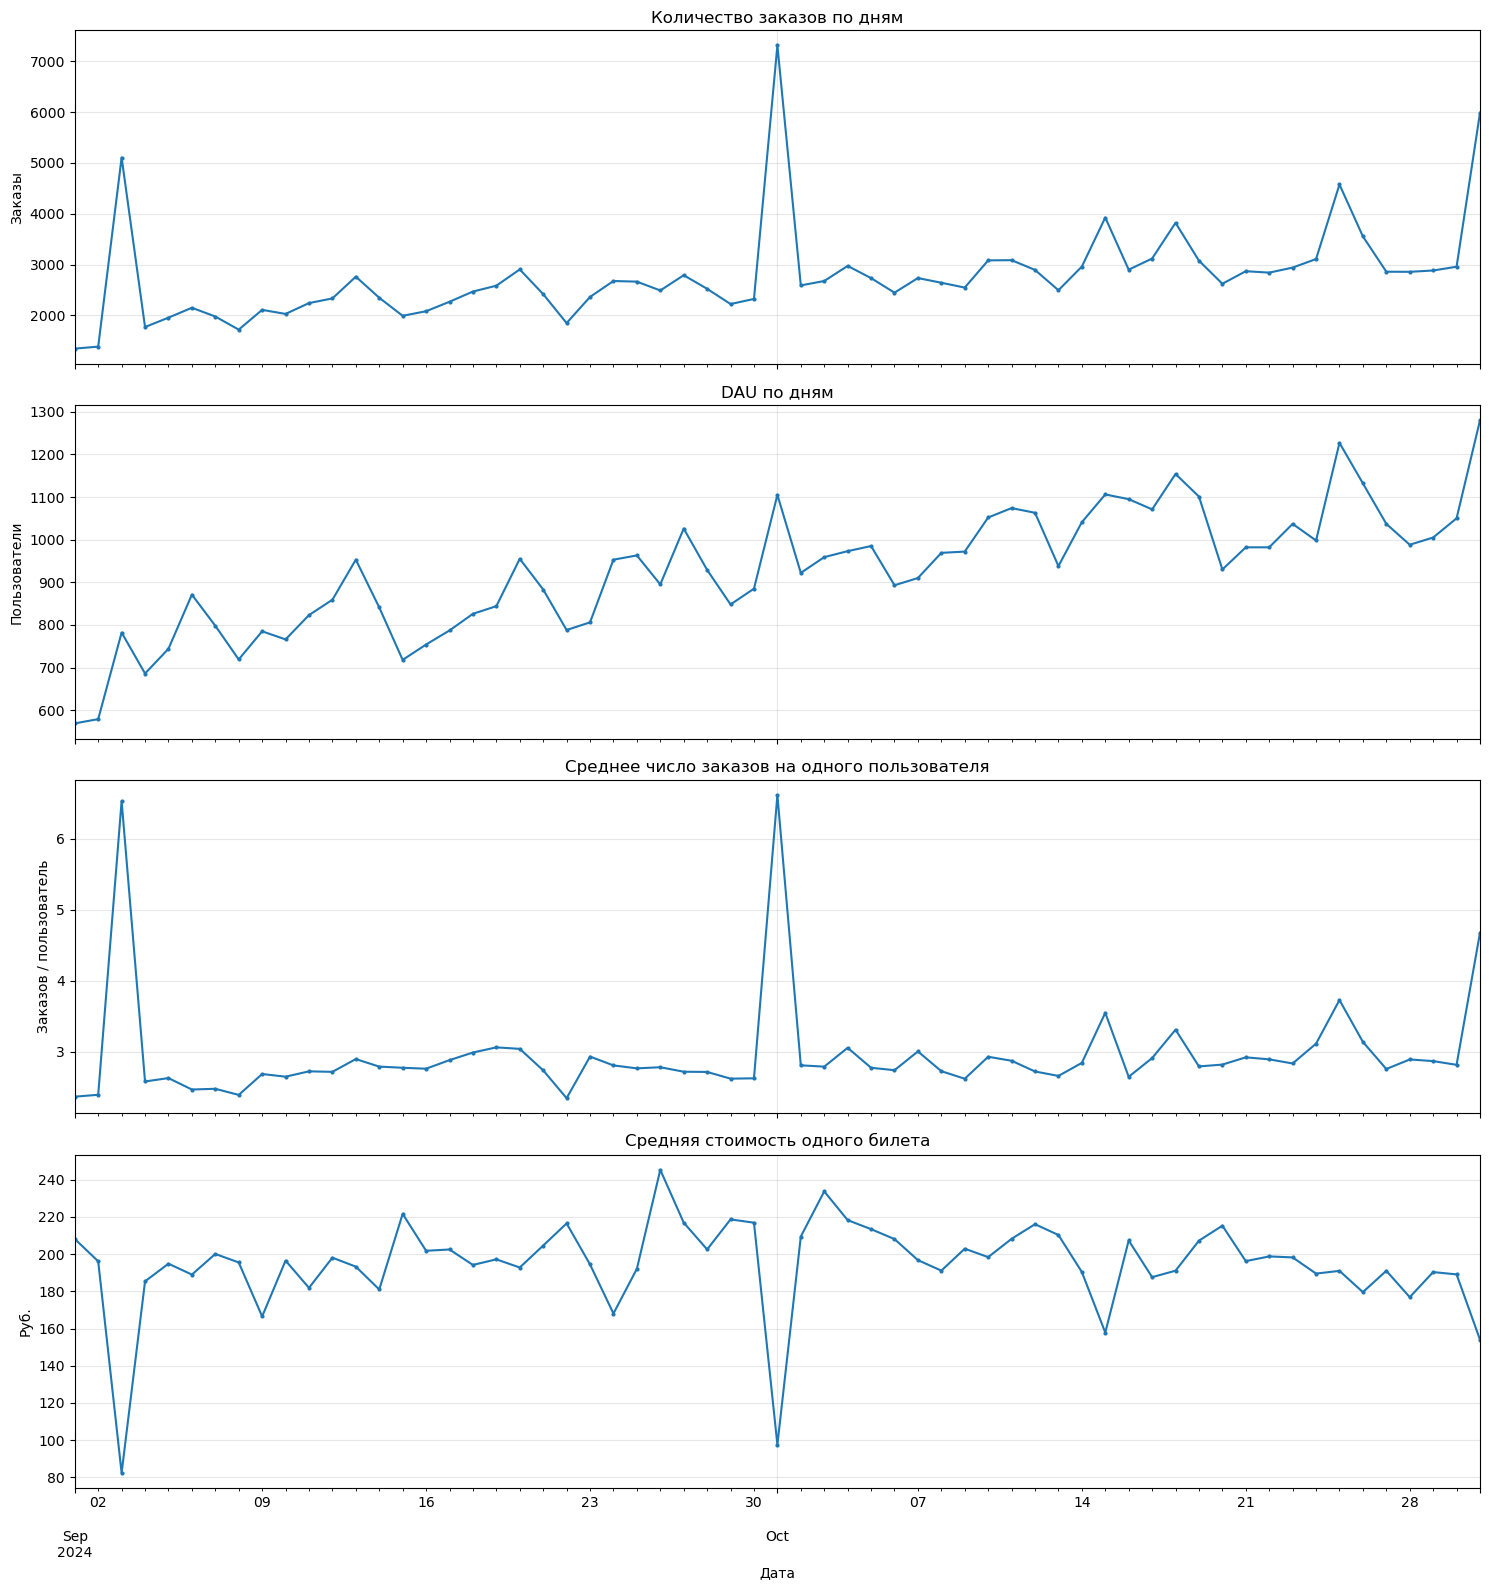

In [43]:
# Для анализа используем только сентябрь и октябрь 2024 года — два осенних месяца, которые представлены в исходном датасете.
autumn_df = df[df['season'] == 'осень'].copy()

daily_activity = (
    autumn_df.groupby(autumn_df['created_dt_msk'].dt.date)
    .agg(
        orders=('order_id', 'count'),
        DAU=('user_id', 'nunique'),
        avg_ticket_revenue=('one_ticket_revenue_rub', 'mean')
    )
)

daily_activity['orders_per_user'] = (
    daily_activity['orders'] / daily_activity['DAU']
)

daily_activity.index = pd.to_datetime(daily_activity.index)

print('Ежедневная динамика активности пользователей:')
display(daily_activity.round(2))

# Четыре показателя на одной фигуре
fig, axes = plt.subplots(4, 1, figsize=(15, 16), sharex=True)

daily_activity['orders'].plot(ax=axes[0], marker='o', markersize=2)
axes[0].set_title('Количество заказов по дням')
axes[0].set_ylabel('Заказы')
axes[0].grid(alpha=0.3)

daily_activity['DAU'].plot(ax=axes[1], marker='o', markersize=2)
axes[1].set_title('DAU по дням')
axes[1].set_ylabel('Пользователи')
axes[1].grid(alpha=0.3)

daily_activity['orders_per_user'].plot(ax=axes[2], marker='o', markersize=2)
axes[2].set_title('Среднее число заказов на одного пользователя')
axes[2].set_ylabel('Заказов / пользователь')
axes[2].grid(alpha=0.3)

daily_activity['avg_ticket_revenue'].plot(ax=axes[3], marker='o', markersize=2)
axes[3].set_title('Средняя стоимость одного билета')
axes[3].set_ylabel('Руб.')
axes[3].set_xlabel('Дата')
axes[3].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Средние показатели по дням недели:


,weekday_num,weekday,avg_orders,avg_DAU,avg_orders_per_user,avg_ticket_revenue
0,0,Понедельник,2410.33,858.89,2.79,192.860001
1,1,Вторник,3520.33,939.44,3.72,165.000000
2,2,Среда,2565.33,930.44,2.76,195.580002
3,3,Четверг,3038.00,966.89,3.07,199.830002
4,4,Пятница,3133.25,1029.12,3.01,200.039993
5,5,Суббота,2691.25,966.50,2.77,200.529999
6,6,Воскресенье,2173.67,826.67,2.61,209.429993


Сравнение будней и выходных:


,avg_daily_orders,avg_daily_DAU,avg_orders_per_user,avg_ticket_revenue,days
period,,,,,
Будни,2928.91,943.05,3.07,190.449997,44
Выходные,2417.24,892.47,2.69,205.240005,17


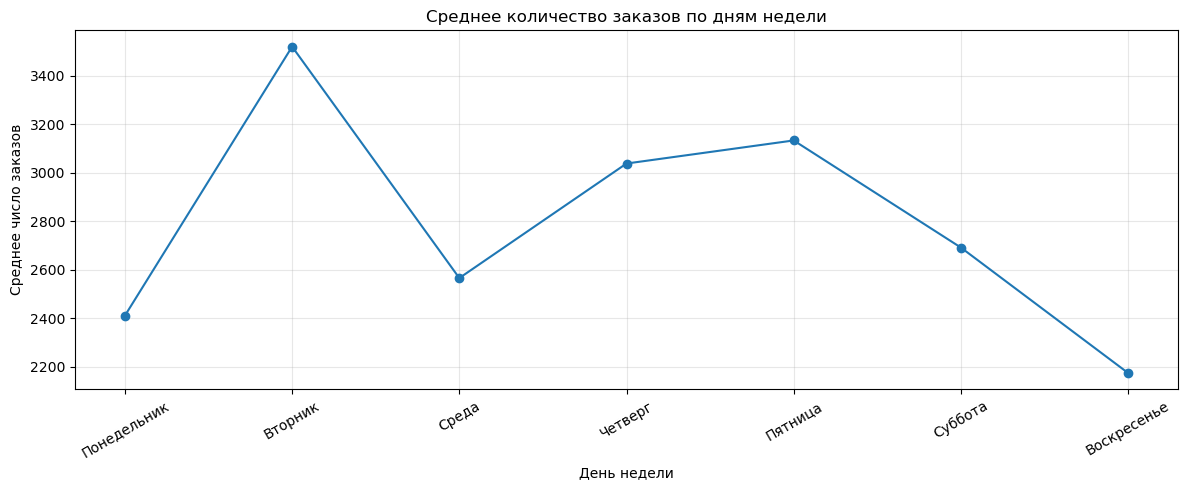

In [44]:
# Недельная цикличность
daily_week = daily_activity.copy()
daily_week['weekday_num'] = daily_week.index.weekday
weekday_names = {
    0: 'Понедельник', 1: 'Вторник', 2: 'Среда',
    3: 'Четверг', 4: 'Пятница', 5: 'Суббота', 6: 'Воскресенье'
}
daily_week['weekday'] = daily_week['weekday_num'].map(weekday_names)
daily_week['period'] = np.where(
    daily_week['weekday_num'] < 5, 'Будни', 'Выходные'
)

weekday_activity = (
    daily_week.groupby(['weekday_num', 'weekday'])
    .agg(
        avg_orders=('orders', 'mean'),
        avg_DAU=('DAU', 'mean'),
        avg_orders_per_user=('orders_per_user', 'mean'),
        avg_ticket_revenue=('avg_ticket_revenue', 'mean')
    )
    .reset_index()
    .sort_values('weekday_num')
)

print('Средние показатели по дням недели:')
display(weekday_activity.round(2))

weekday_period = (
    daily_week.groupby('period')
    .agg(
        avg_daily_orders=('orders', 'mean'),
        avg_daily_DAU=('DAU', 'mean'),
        avg_orders_per_user=('orders_per_user', 'mean'),
        avg_ticket_revenue=('avg_ticket_revenue', 'mean'),
        days=('orders', 'size')
    )
    .reindex(['Будни', 'Выходные'])
)

print('Сравнение будней и выходных:')
display(weekday_period.round(2))

plt.figure(figsize=(12, 5))
plt.plot(
    weekday_activity['weekday'],
    weekday_activity['avg_orders'],
    marker='o'
)
plt.title('Среднее количество заказов по дням недели')
plt.xlabel('День недели')
plt.ylabel('Среднее число заказов')
plt.xticks(rotation=30)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---

#### Промежуточный вывод по разделу 3.2

Осенью 2024 года пользовательская активность заметно меняется от дня к дню. Среднее значение за два осенних месяца составляет около **2 786 заказов в день** и **929 активных пользователей в день**. В среднем на одного пользователя приходится около **2,96 заказа**, а средняя стоимость одного билета составляет около **194,6 руб.**

В данных наблюдаются отдельные дни с резкими всплесками заказов и DAU. Поэтому ежедневная динамика не является полностью равномерной: активность зависит от конкретной даты.

Недельная цикличность выражена достаточно заметно. В среднем в будни фиксируется около **2 929 заказов в день**, а в выходные — около **2 417**, то есть будни характеризуются более высокой пользовательской активностью. Среднее количество заказов на пользователя также выше в будни — около **3,07** против **2,69** в выходные.

При этом средняя стоимость одного билета, наоборот, немного выше в выходные: около **205,2 руб.** против **190,4 руб.** в будни. Получается, что в будние дни пользователи совершают больше заказов и в среднем активнее, а в выходные при меньшем количестве заказов средняя стоимость билета несколько выше.

---

#### 3.3. Популярные события и партнёры

Количество регионов в осенних данных: 79
Регионы по количеству заказов:


,unique_events,orders,revenue,unique_events_share,orders_share,revenue_share
region_name,,,,,,
Каменевский регион,3946,47511,3.192564e+07,24.84,27.96,35.959999
Североярская область,2620,20883,1.250175e+07,16.49,12.29,14.080000
Медовская область,368,12046,2.357040e+06,2.32,7.09,2.650000
Широковская область,796,8672,4.294911e+06,5.01,5.10,4.840000
Озернинский край,296,7579,6.914090e+06,1.86,4.46,7.790000
Светополянский округ,762,4831,2.207144e+06,4.80,2.84,2.490000
Малиновоярский округ,137,4607,3.902012e+06,0.86,2.71,4.400000
Серебринская область,456,4477,1.592135e+06,2.87,2.63,1.790000
Яблоневская область,431,4220,2.017506e+06,2.71,2.48,2.270000


Регионы по количеству уникальных мероприятий:


,unique_events,orders,revenue,unique_events_share,orders_share,revenue_share
region_name,,,,,,
Каменевский регион,3946,47511,3.192564e+07,24.84,27.96,35.959999
Североярская область,2620,20883,1.250175e+07,16.49,12.29,14.080000
Широковская область,796,8672,4.294911e+06,5.01,5.10,4.840000
Светополянский округ,762,4831,2.207144e+06,4.80,2.84,2.490000
Речиновская область,529,3576,1.773750e+06,3.33,2.10,2.000000
Серебринская область,456,4477,1.592135e+06,2.87,2.63,1.790000
Яблоневская область,431,4220,2.017506e+06,2.71,2.48,2.270000
Тепляковская область,420,2486,7.759749e+05,2.64,1.46,0.870000
Горицветская область,406,3234,1.131096e+06,2.56,1.90,1.270000


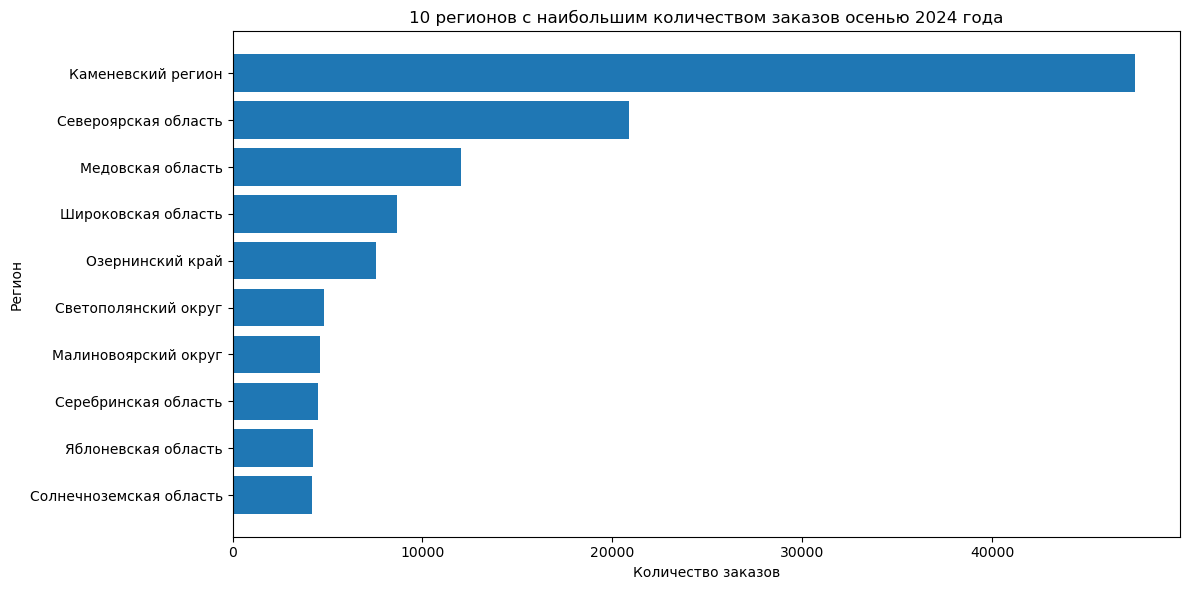

In [45]:
# Анализируем только осень 2024 года, как в предыдущем разделе.
autumn_df = df[df['season'] == 'осень'].copy()

# Регионы: уникальное количество мероприятий и число заказов.
# Дополнительно рассчитываем доли мероприятий, заказов и выручки.
region_table = (
    autumn_df.dropna(subset=['region_name'])
    .groupby('region_name', observed=True)
    .agg(
        unique_events=('event_id', 'nunique'),
        orders=('order_id', 'count'),
        revenue=('revenue_rub', 'sum')
    )
)

for column in ['unique_events', 'orders', 'revenue']:
    region_table[f'{column}_share'] = (
        region_table[column] / region_table[column].sum() * 100
    )

region_table = region_table.sort_values('orders', ascending=False)

print(f'Количество регионов в осенних данных: {len(region_table)}')
print('Регионы по количеству заказов:')
display(region_table.head(15).round(2))

# Топ регионов по разнообразию мероприятий
print('Регионы по количеству уникальных мероприятий:')
display(
    region_table.sort_values('unique_events', ascending=False)
    .head(15)
    .round(2)
)

# Визуализация: лидеры по заказам
top_regions = region_table.head(10).sort_values('orders')
plt.figure(figsize=(12, 6))
plt.barh(top_regions.index, top_regions['orders'])
plt.xlabel('Количество заказов')
plt.ylabel('Регион')
plt.title('10 регионов с наибольшим количеством заказов осенью 2024 года')
plt.tight_layout()
plt.show()

Количество билетных партнёров в осенних данных: 35
Партнёры по количеству обработанных заказов:


,unique_events,orders,revenue,unique_events_share,orders_share,revenue_share
service_name,,,,,,
Билеты без проблем,2844,32709,1.361968e+07,16.42,19.24,15.34
Лови билет!,3621,25849,1.064498e+07,20.91,15.21,11.99
Билеты в руки,2462,25678,7.715562e+06,14.22,15.11,8.69
Мой билет,1013,19681,1.180890e+07,5.85,11.58,13.30
Облачко,1413,15616,1.245903e+07,8.16,9.19,14.03
Лучшие билеты,1390,12440,1.742777e+06,8.03,7.32,1.96
Весь в билетах,608,9641,1.016970e+07,3.51,5.67,11.45
Прачечная,728,5831,2.647692e+06,4.20,3.43,2.98
Тебе билет!,858,3778,2.223915e+06,4.95,2.22,2.50


Партнёры по суммарной выручке:


,unique_events,orders,revenue,unique_events_share,orders_share,revenue_share
service_name,,,,,,
Билеты без проблем,2844,32709,1.361968e+07,16.42,19.24,15.34
Облачко,1413,15616,1.245903e+07,8.16,9.19,14.03
Мой билет,1013,19681,1.180890e+07,5.85,11.58,13.30
Лови билет!,3621,25849,1.064498e+07,20.91,15.21,11.99
Весь в билетах,608,9641,1.016970e+07,3.51,5.67,11.45
Билеты в руки,2462,25678,7.715562e+06,14.22,15.11,8.69
Край билетов,194,3062,3.222585e+06,1.12,1.80,3.63
Яблоко,538,3496,2.831862e+06,3.11,2.06,3.19
Прачечная,728,5831,2.647692e+06,4.20,3.43,2.98


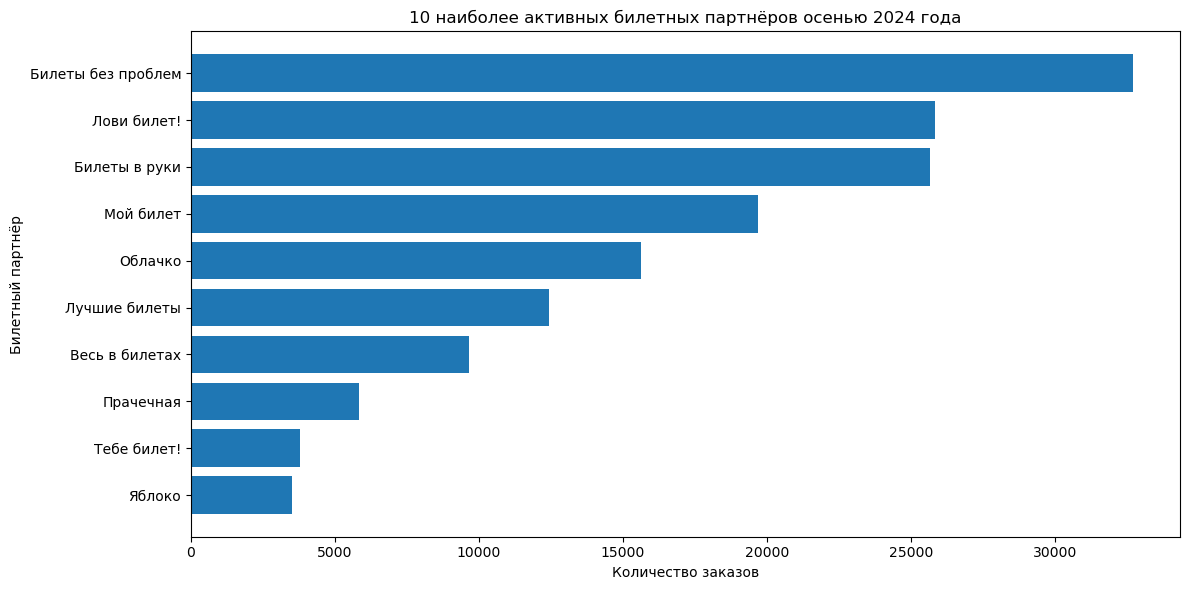

Топ-5 регионов формируют 56.90% заказов и 65.32% выручки.
Топ-5 партнёров формируют 70.33% заказов и 63.35% выручки.


In [46]:
# Билетные партнёры
partner_table = (
    autumn_df.dropna(subset=['service_name'])
    .groupby('service_name', observed=True)
    .agg(
        unique_events=('event_id', 'nunique'),
        orders=('order_id', 'count'),
        revenue=('revenue_rub', 'sum')
    )
)

for column in ['unique_events', 'orders', 'revenue']:
    partner_table[f'{column}_share'] = (
        partner_table[column] / partner_table[column].sum() * 100
    )

partner_table = partner_table.sort_values('orders', ascending=False)

print(f'Количество билетных партнёров в осенних данных: {len(partner_table)}')
print('Партнёры по количеству обработанных заказов:')
display(partner_table.head(15).round(2))

print('Партнёры по суммарной выручке:')
display(
    partner_table.sort_values('revenue', ascending=False)
    .head(15)
    .round(2)
)

# Визуализация: лидеры по заказам
top_partners = partner_table.head(10).sort_values('orders')
plt.figure(figsize=(12, 6))
plt.barh(top_partners.index, top_partners['orders'])
plt.xlabel('Количество заказов')
plt.ylabel('Билетный партнёр')
plt.title('10 наиболее активных билетных партнёров осенью 2024 года')
plt.tight_layout()
plt.show()

# Доля пяти крупнейших категорий
top5_region_orders_share = region_table.head(5)['orders_share'].sum()
top5_region_revenue_share = region_table.head(5)['revenue_share'].sum()
top5_partner_orders_share = partner_table.head(5)['orders_share'].sum()
top5_partner_revenue_share = partner_table.head(5)['revenue_share'].sum()

print(f'Топ-5 регионов формируют {top5_region_orders_share:.2f}% заказов и {top5_region_revenue_share:.2f}% выручки.')
print(f'Топ-5 партнёров формируют {top5_partner_orders_share:.2f}% заказов и {top5_partner_revenue_share:.2f}% выручки.')

---

#### Промежуточный вывод по разделу 3.3

Осенью в данных представлены **79 регионов** и **35 билетных партнёров**, поэтому распределение активности между категориями неоднородно.

Явным лидером среди регионов является **Каменевский регион**: на него приходится около **28% всех заказов** и **36% выручки** осеннего периода. На втором месте по заказам находится Североярская область — около 12,3%. Топ-5 регионов вместе формируют **56,9% заказов и 65,3% выручки**, поэтому региональная активность заметно сконцентрирована у нескольких лидеров. При этом лидерство по разнообразию мероприятий не полностью совпадает с лидерством по числу заказов: большое количество доступных мероприятий само по себе не гарантирует такой же доли заказов.

Среди билетных партнёров лидирует **«Билеты без проблем»** — около **19,2% заказов**. Далее следуют «Лови билет!» и «Билеты в руки» — примерно по 15% заказов каждый. Топ-5 партнёров обеспечивают около **70,3% заказов и 63,4% выручки**. При этом распределение выручки отличается от распределения количества заказов: например, отдельные партнёры имеют меньшую долю заказов, но более высокую долю выручки.

Следовательно, в осенний период наблюдается выраженная концентрация активности: несколько регионов и билетных партнёров формируют основную часть заказов и выручки, однако остальная часть распределена между большим количеством менее активных категорий.

---

#### Шаг 4. Статистический анализ данных

Коллеги из продуктового отдела хотят проверить две гипотезы о большей активности пользователей мобильных устройств. Для анализа используем только осенние данные — сентябрь и октябрь 2024 года.

Единицей наблюдения будет пользователь. Чтобы группы были независимыми, в сравнение включаем только пользователей, которые в осенний период использовали один тип устройства: `mobile` или `desktop`. Пользователи, которые совершали заказы с обоих типов устройств, исключаются из сравнения, поскольку их нельзя однозначно отнести к одной группе.

Для каждой группы рассчитаем количество заказов на пользователя. Для анализа времени между заказами используем среднее значение `days_since_prev` для каждого пользователя; пользователи, у которых осенью был только один заказ и поэтому нет значения интервала, в этот расчёт не включаются.

Распределения показателей имеют заметную асимметрию и выбросы, а дисперсии групп различаются. При этом проверяются гипотезы именно о **средних значениях**, поэтому используем **двухвыборочный t-тест Уэлча** : он предназначен для сравнения средних двух независимых групп и не требует предположения о равенстве дисперсий. При больших размерах выборок нормальность среднего дополнительно обеспечивается центральной предельной теоремой.

---

#### Формулировка гипотез — среднее количество заказов

**Нулевая гипотеза (H₀):** Среднее количество заказов на одного пользователя мобильного приложения не выше, чем у пользователей стационарных устройств. То есть разница средних значений меньше или равна нулю: μ_mobile − μ_desktop ≤ 0.

**Альтернативная гипотеза (H₁):** Среднее количество заказов на одного пользователя мобильного приложения выше, чем у пользователей стационарных устройств. То есть мобильные пользователи совершают статистически значимо больше заказов: μ_mobile − μ_desktop > 0.

#### Формулировка гипотез — среднее время между заказами

**Нулевая гипотеза (H₀):** Среднее время между заказами пользователей мобильных приложений не выше, чем у пользователей стационарных устройств. То есть разница средних значений меньше или равна нулю: μ_mobile − μ_desktop ≤ 0.

**Альтернативная гипотеза (H₁):** Среднее время между заказами пользователей мобильных приложений выше, чем у пользователей стационарных устройств. То есть мобильные пользователи имеют статистически значимо больший интервал между заказами: μ_mobile − μ_desktop > 0.

Распределение пользователей по типу устройства:


,count,mean,median,std
user_device,,,,
desktop,1633,1.98,1.0,3.06
mobile,10959,2.87,2.0,4.11


Среднее время между заказами:


,count,mean,median,std
user_device,,,,
desktop,894,31.540001,17.0,36.619999
mobile,7063,25.309999,14.0,30.250000


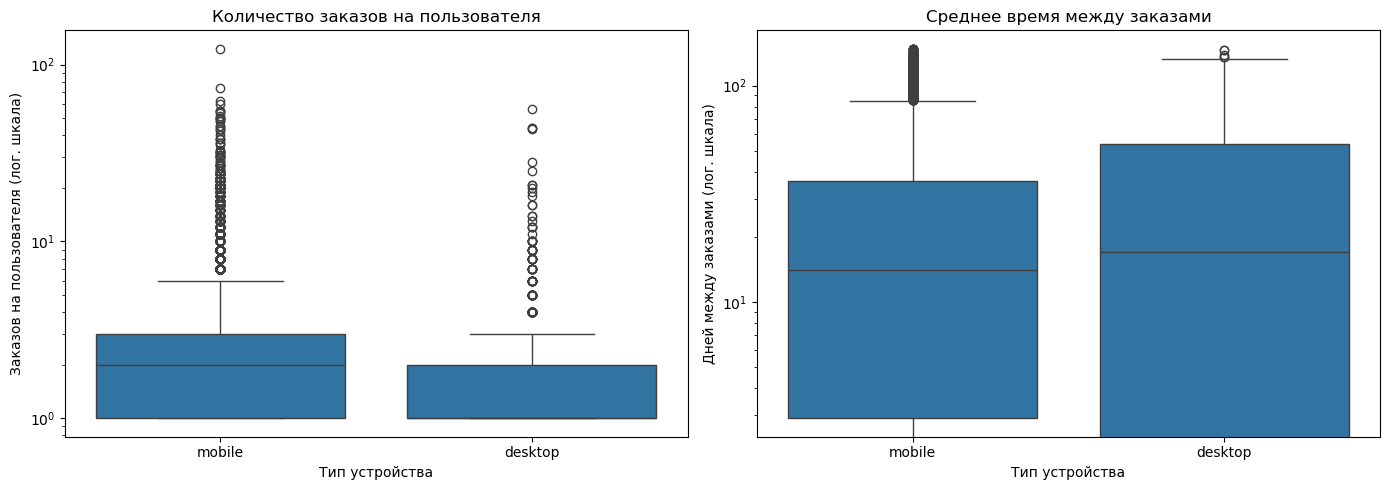

In [47]:
from scipy import stats

# Только осень 2024 года
autumn_test = df[(df['created_dt_msk'] >= '2024-09-01') &
                 (df['created_dt_msk'] < '2024-11-01')].copy()

# Определяем пользователей, которые осенью использовали только один тип устройства.
# Пользователей с двумя типами устройств исключаем, чтобы группы были независимыми.
user_devices = (
    autumn_test.groupby('user_id')['device_type_canonical']
    .agg(lambda x: x.dropna().unique())
)
exclusive_users = user_devices[user_devices.apply(len) == 1].apply(lambda x: x[0])

autumn_test = autumn_test[autumn_test['user_id'].isin(exclusive_users.index)].copy()
autumn_test['user_device'] = autumn_test['user_id'].map(exclusive_users)

# Метрики на уровне пользователя
user_metrics = (
    autumn_test.groupby(['user_id', 'user_device'])
    .agg(
        orders=('order_id', 'count'),
        avg_days_between_orders=('days_since_prev', 'mean')
    )
    .reset_index()
)

print('Распределение пользователей по типу устройства:')
display(user_metrics.groupby('user_device')['orders'].agg(['count', 'mean', 'median', 'std']).round(2))

print('Среднее время между заказами:')
display(
    user_metrics.groupby('user_device')['avg_days_between_orders']
    .agg(['count', 'mean', 'median', 'std'])
    .round(2)
)

# Визуально сравним распределения. Логарифмическая шкала нужна из-за сильной асимметрии.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=user_metrics, x='user_device', y='orders', ax=axes[0])
axes[0].set_yscale('log')
axes[0].set_title('Количество заказов на пользователя')
axes[0].set_xlabel('Тип устройства')
axes[0].set_ylabel('Заказов на пользователя (лог. шкала)')

sns.boxplot(data=user_metrics.dropna(subset=['avg_days_between_orders']),
            x='user_device', y='avg_days_between_orders', ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_title('Среднее время между заказами')
axes[1].set_xlabel('Тип устройства')
axes[1].set_ylabel('Дней между заказами (лог. шкала)')

plt.tight_layout()
plt.show()

In [48]:
# H0: среднее значение у mobile не выше, чем у desktop.
# H1: среднее значение у mobile выше, чем у desktop.
alpha = 0.05

mobile_orders = user_metrics.loc[user_metrics['user_device'] == 'mobile', 'orders']
desktop_orders = user_metrics.loc[user_metrics['user_device'] == 'desktop', 'orders']

mobile_gap = user_metrics.loc[user_metrics['user_device'] == 'mobile', 'avg_days_between_orders'].dropna()
desktop_gap = user_metrics.loc[user_metrics['user_device'] == 'desktop', 'avg_days_between_orders'].dropna()

orders_test = stats.ttest_ind(
    mobile_orders, desktop_orders, equal_var=False, alternative='greater'
)
gap_test = stats.ttest_ind(
    mobile_gap, desktop_gap, equal_var=False, alternative='greater'
)

print('=== Гипотеза 1: среднее количество заказов ===')
print(f"Mobile: {mobile_orders.mean():.2f}; Desktop: {desktop_orders.mean():.2f}")
print(f"Разница: {mobile_orders.mean() - desktop_orders.mean():.2f} заказа")
print(f"Относительное изменение: {(mobile_orders.mean() / desktop_orders.mean() - 1) * 100:.1f}%")
print(f"t-статистика: {orders_test.statistic:.3f}; p-value: {orders_test.pvalue:.6g}")
print('Решение:', 'отвергаем H0' if orders_test.pvalue < alpha else 'не отвергаем H0')

print('\n=== Гипотеза 2: среднее время между заказами ===')
print(f"Mobile: {mobile_gap.mean():.2f} дня; Desktop: {desktop_gap.mean():.2f} дня")
print(f"Разница: {mobile_gap.mean() - desktop_gap.mean():.2f} дня")
print(f"Относительное изменение: {(mobile_gap.mean() / desktop_gap.mean() - 1) * 100:.1f}%")
print(f"t-статистика: {gap_test.statistic:.3f}; p-value: {gap_test.pvalue:.6g}")
print('Решение:', 'отвергаем H0' if gap_test.pvalue < alpha else 'не отвергаем H0')

=== Гипотеза 1: среднее количество заказов ===
Mobile: 2.87; Desktop: 1.98
Разница: 0.89 заказа
Относительное изменение: 45.0%
t-статистика: 10.424; p-value: 2.96712e-25
Решение: отвергаем H0

=== Гипотеза 2: среднее время между заказами ===
Mobile: 25.31 дня; Desktop: 31.54 дня
Разница: -6.23 дня
Относительное изменение: -19.8%
t-статистика: -4.884; p-value: 0.999999
Решение: не отвергаем H0


---

#### Промежуточный вывод по шагу 4

Первая гипотеза подтверждается: среднее количество заказов на пользователя мобильного сегмента составляет **2,87**, а стационарного — **1,98**. Разница составляет около **45%**, а односторонний t-тест Уэлча даёт статистически значимый результат (`p < 0,001`). Нулевая гипотеза отвергается, поэтому данные поддерживают предположение о более высокой частоте заказов у пользователей мобильных устройств.

Вторая гипотеза **не подтверждается**. Среднее время между заказами у мобильного сегмента составляет около **25,30 дня**, а у desktop — **31,54 дня**. Полученное направление отличается от предполагаемого: мобильные пользователи в среднем возвращаются за следующим заказом раньше. При проверке гипотезы «время между заказами у mobile выше» `p ≈ 1`, поэтому нулевую гипотезу не отвергаем.

Следовательно, осенью мобильный сегмент действительно характеризуется более высокой частотой покупок, однако это не связано с большим интервалом между заказами: наоборот, интервал у мобильных пользователей меньше.

---

### Шаг 5. Общий вывод и рекомендации

В работе проанализированы данные о заказах билетов сервиса Яндекс Афиша за период с июня по октябрь 2024 года. После объединения источников, обработки пропусков, удаления отрицательной выручки и дубликатов для анализа осталось около **290 тыс. заказов**. Для сезонного анализа использовались летние месяцы июнь–август и осенние месяцы сентябрь–октябрь, поскольку данных за ноябрь в датасете нет.

Основной результат — заметное усиление спроса осенью. Количество заказов выросло с **34 568 в июне** до **100 082 в октябре**, а осенний объём заказов оказался на **41,1% выше летнего**. При этом изменилась структура спроса: доля концертов снизилась с 42,9% до 37,5%, а доля театра выросла с 20,1% до 25,4%. Особенно заметно увеличилась доля спортивных мероприятий — с 2,5% до 11,1%. Около 80% заказов в обоих сезонах приходится на мобильные устройства.

Стоимость билета осенью изменилась неодинаково в разных категориях. Средняя выручка с одного билета выросла у стендапа (+10,1%) и выставок (+6,5%), но снизилась у театра (−17,7%), ёлок (−15,2%) и концертов (−10,1%). Поэтому общий рост числа заказов нельзя объяснять ростом средней стоимости билета: осеннее увеличение спроса в большей степени связано с объёмом и изменением структуры заказов.

Осенняя активность пользователей имеет выраженную недельную цикличность. В среднем в будни оформлялось около 2 929 заказов в день против 2 417 в выходные, а заказов на одного пользователя — 3,07 против 2,69. При этом средняя стоимость билета в выходные немного выше. Это показывает, что для продвижения важны не только сезонные, но и календарные закономерности спроса.

Региональное и партнёрское распределение также неоднородно. В осенних данных представлены 79 регионов и 35 билетных партнёров. Каменевский регион лидирует по числу заказов и формирует около 28% заказов и 36% выручки; пять крупнейших регионов дают 56,9% заказов и 65,3% выручки. Среди партнёров по числу заказов лидируют «Билеты без проблем» (19,2%), «Лови билет!» и «Билеты в руки». Пять крупнейших партнёров обеспечивают около 70,3% заказов и 63,4% выручки. Это указывает на заметную концентрацию продаж.

Проверка гипотез показала, что пользователи мобильного сегмента осенью в среднем оформляют больше заказов, чем пользователи desktop. Первая гипотеза статистически подтверждена. Вторая гипотеза не подтверждена: среднее время между заказами у мобильного сегмента ниже, а не выше.

**Рекомендации:** в первую очередь стоит учитывать мобильный канал как основной источник пользовательской активности; отдельно работать с категориями, которые усиливают спрос осенью, прежде всего со спортом и театром; при планировании промо учитывать различия между буднями и выходными; контролировать концентрацию продаж у отдельных регионов и партнёров; анализировать не только количество заказов, но и стоимость билета, поскольку рост спроса не всегда сопровождается ростом среднего чека. Для мобильного сегмента также имеет смысл развивать механики повторной покупки и персональные рекомендации, поскольку пользователи этого сегмента совершают заказы чаще.